# Data processing
In this notebook we will repeat what happened in paris_greenview.ipynb but by hexing the data, so first we need to prepare the data into h3 hexagons.

In [37]:
# Import base packages
import os
import json
import pickle
import argparse

# Import external packages
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric.transforms as T
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from torch_geometric.nn.attention import PerformerAttention
from torch_geometric.nn.attention.performer import generalized_kernel
from torch_geometric.nn import GATv2Conv

import numpy as np
import pandas as pd
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
from collections import Counter
import torch_geometric
from torch_geometric.data import InMemoryDataset, Data
from shapely import wkt
import contextily as cx

In [147]:
#load paris geoJson edge and nodes
paris_edges = gpd.read_file('paris_edges.geojson')
paris_nodes = gpd.read_file('paris_nodes.geojson')
paris_nodes.columns

Index(['osmid', 'x', 'y', 'Node Density', 'Street Length', 'Degree',
       'Clustering', 'Clustering (Weighted)', 'Closeness Centrality',
       'Betweenness Centrality', 'Eigenvector Centrality', 'Katz Centrality',
       'PageRank', 'Footprint Proportion', 'Footprint Mean', 'Footprint Stdev',
       'Perimeter Total', 'Perimeter Mean', 'Perimeter Stdev',
       'Complexity Mean', 'Complexity Stdev', 'Counts', 'PopSum', 'Men',
       'Women', 'Elderly', 'Youth', 'Children', 'Civic', 'Commercial',
       'Entertainment', 'Food', 'Healthcare', 'Institutional', 'Recreational',
       'Social', 'Green View', 'Sky View', 'Building View', 'Road View',
       'geometry'],
      dtype='object')

Text(0.5, 1.0, 'Paris Edges and Nodes')

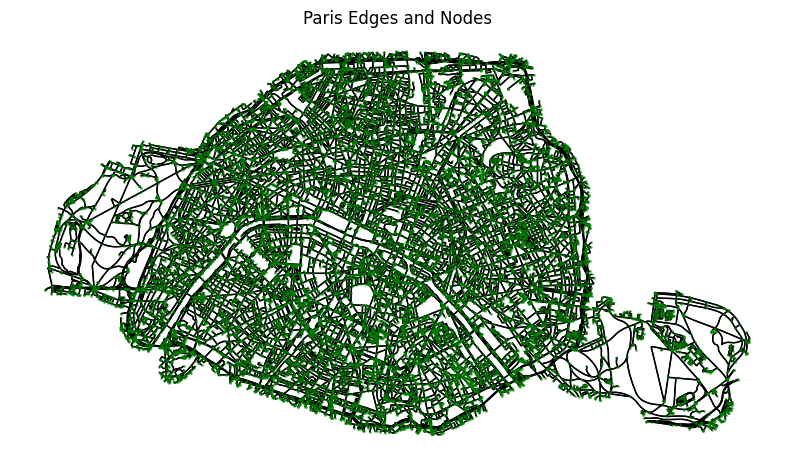

In [3]:
f, ax = plt.subplots(figsize=(10, 10))
paris_edges.plot(ax=ax, color='black', linewidth=1, zorder =1)
paris_nodes.plot(ax=ax, color='green', markersize=1, zorder=2, alpha=0.5)
ax.set_axis_off()
plt.title('Paris Edges and Nodes')

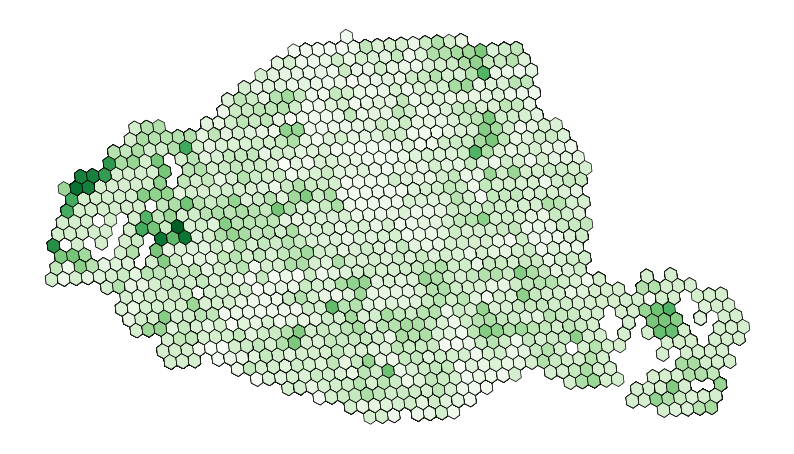

In [4]:
import h3pandas
#h3 grid of Paris from the 100m nodes 
paris_nodes.crs

paris_nodes
dfh3 = paris_nodes.h3.geo_to_h3(9)
dfh3 = dfh3.h3.h3_to_geo_boundary()
f, ax = plt.subplots(1, 1, figsize=(10, 10))
dfh3.plot(
    column = 'Green View', cmap = 'Greens', edgecolor='black', linewidth=0.5, ax = ax)
ax.set_axis_off()

dfh3.drop(columns=['geometry'], inplace=True)

In [5]:
h3_grouped = dfh3.groupby(['h3_09']).mean().reset_index()
h3_grouped.set_index('h3_09', inplace=True)
h3_nodes = h3_grouped.h3.h3_to_geo_boundary()
h3_nodes = gpd.GeoDataFrame(h3_grouped, geometry= h3_nodes['geometry'], crs = paris_nodes.crs)
h3_nodes.x = h3_nodes.geometry.centroid.x
h3_nodes.y = h3_nodes.geometry.centroid.y
print(h3_nodes.shape)


(1228, 41)


/var/folders/2g/xkdpgwks0kzg848hbvw_8h1m0000gn/T/ipykernel_41563/1105341623.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  h3_nodes.x = h3_nodes.geometry.centroid.x
/var/folders/2g/xkdpgwks0kzg848hbvw_8h1m0000gn/T/ipykernel_41563/1105341623.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  h3_nodes.y = h3_nodes.geometry.centroid.y


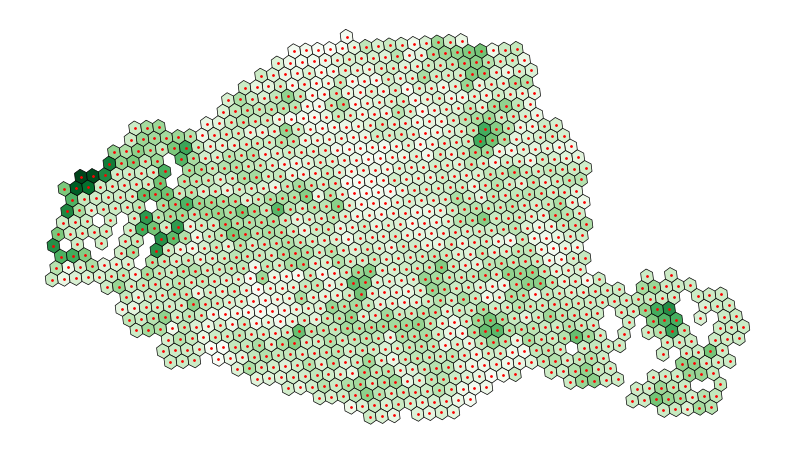

In [6]:
f, ax = plt.subplots(1, 1, figsize=(10, 10))
h3_nodes.plot(
    column = 'Green View', cmap = 'Greens', edgecolor='black', linewidth=0.5, ax = ax)
ax.set_axis_off()
ax.plot(h3_nodes.x, h3_nodes.y, 'o', color='red', markersize=1, alpha=1)

So now we succefully created the grid and averaged all the properties, x and y are the coordinates of the center of the hexagon, and the value is the average of all the points in that hexagon. 

In [7]:
h3_gdf_reset = h3_nodes.copy()
h3_gdf_reset.reset_index(drop= False , inplace=True)

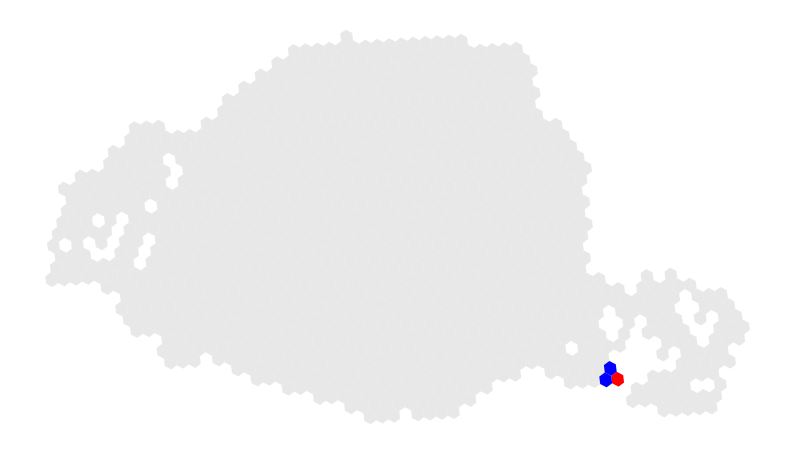

In [8]:
# given a node find the first neighbors using k_ring


cell = h3_nodes[h3_nodes.index == '891fb46410fffff']
#cell = h3_gdf.iloc[[0]]
neighbors_index = cell.h3.k_ring(1,explode=True)
neighbors_index = neighbors_index['h3_k_ring'].values
neighbors_index = neighbors_index[neighbors_index != cell.index[0]]

neighbors = h3_nodes[h3_nodes.index.isin(neighbors_index)] 

# Visualize the neighbors
f, ax = plt.subplots(1, 1, figsize=(10, 10))
h3_nodes.plot(color='lightgrey', ax=ax, alpha=0.5)
cell.plot(color='red', ax=ax)
neighbors.plot(color='blue', ax=ax)
ax.set_axis_off()

Now we have the neighbors of a cell, we need to create an edge index that finds the neighbors of each cell.

In [9]:
# find the neighbors of all the nodes
neighbors_index = h3_nodes.h3.k_ring(1,explode=True)  
neighbors_index =  neighbors_index[neighbors_index['h3_k_ring'] != neighbors_index.index]
neighbors_index = neighbors_index['h3_k_ring']
 

In [10]:
# Create a set of all neighbor pairs (ordered pairs to check symmetry)
neighbor_pairs = set()

# We'll track which cell relates to which neighbor
neighbor_df = neighbors_index.reset_index()

# Add all the (cell, neighbor) pairs to our set
for idx, row in neighbor_df.iterrows():
    cell = row['index']  # The original cell
    neighbor = row['h3_k_ring']  # Its neighbor
    neighbor_pairs.add((cell, neighbor))

# Check for symmetry - for each (A,B) pair, (B,A) should also exist
symmetric = True
missing_pairs = []
for cell, neighbor in neighbor_pairs:
    if (neighbor, cell) not in neighbor_pairs:
        symmetric = False
        missing_pairs.append((neighbor, cell))
        
print(f"Neighbor relationships are symmetric: {symmetric}")
if not symmetric:
    print(f"Found {len(missing_pairs)} missing reverse pairs out of {len(neighbor_pairs)} total pairs")
    print("First few missing pairs:", missing_pairs[:5])

Neighbor relationships are symmetric: False
Found 524 missing reverse pairs out of 7368 total pairs
First few missing pairs: [('891fb464ccbffff', '891fb464cc3ffff'), ('891fb464ccbffff', '891fb464127ffff'), ('891fb46737bffff', '891fb467373ffff'), ('891fb466b1bffff', '891fb466b0bffff'), ('891fb466e17ffff', '891fb466e13ffff')]


In [11]:
#for all missing pairs check if the first cell of the pair is empty ---> this comes from observations I did on this missing pairs graphically
missing_pairs = [(cell, neighbor) for cell, neighbor in missing_pairs if h3_nodes[h3_nodes.index == cell].empty]
print(f"Found {len(missing_pairs)} missing pairs where the first cell is empty")

# delete the missing pairs from the neighbors_index
neighbors_index = neighbors_index[~neighbors_index.isin([cell for cell, _ in missing_pairs])]

#re create the neighbors pairs
neighbor_pairs = set()
neighbor_df = neighbors_index.reset_index()
for idx, row in neighbor_df.iterrows():
    cell = row['index']  # The original cell
    neighbor = row['h3_k_ring']  # Its neighbor
    neighbor_pairs.add((cell, neighbor))
# Check for symmetry - for each (A,B) pair, (B,A) should also exist
symmetric = True
missing_pairs = []
for cell, neighbor in neighbor_pairs:
    if (neighbor, cell) not in neighbor_pairs:
        symmetric = False
        missing_pairs.append((neighbor, cell))
print(f"Neighbor relationships are symmetric: {symmetric}")
if not symmetric:
    print(f"Found {len(missing_pairs)} missing reverse pairs out of {len(neighbor_pairs)} total pairs")
    print("First few missing pairs:", missing_pairs[:5])

Found 524 missing pairs where the first cell is empty
Neighbor relationships are symmetric: True


we have exluded empy cells, and we have all the neighbors pairs existing in the grid.

In [12]:
from shapely.geometry import LineString
#use neighbor pairs to create the edges in a geoDataFrame
h3_edges = pd.DataFrame(neighbor_pairs, columns=['source', 'target'])
h3_edges['geometry'] = h3_edges.apply(lambda row: LineString([h3_nodes.loc[row['source'], 'geometry'].centroid, h3_nodes.loc[row['target'], 'geometry'].centroid]), axis=1)
h3_edges = gpd.GeoDataFrame(h3_edges, geometry='geometry', crs=paris_nodes.crs)
h3_edges = h3_edges[['source', 'target', 'geometry']]
h3_edges.reset_index(drop=True, inplace=True)
h3_edges.shape

(6844, 3)

Text(0.5, 1.0, 'Edges and Nodes')

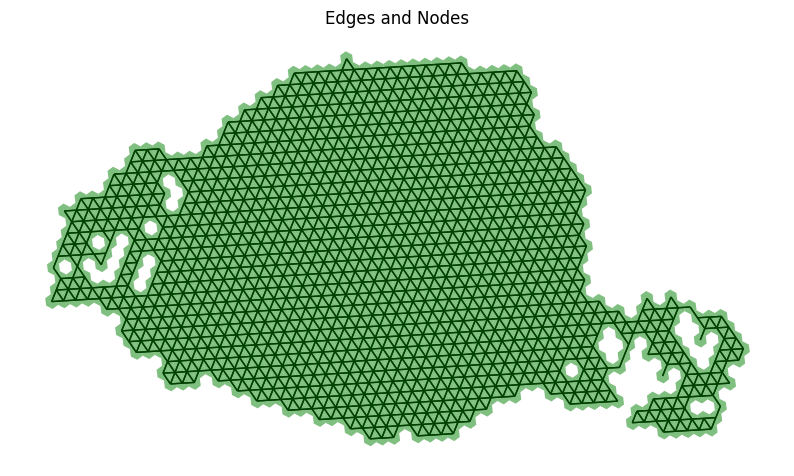

In [16]:
f, ax = plt.subplots(1, 1, figsize=(10, 10))
h3_edges.plot(ax=ax, color='black', linewidth=1, zorder =1)
h3_nodes.plot(ax=ax, color='green', markersize=1, zorder=2, alpha=0.5)
ax.set_axis_off()
plt.title('Edges and Nodes')

And now we officially have the graph, we can use it to do whatever, since the edge also code the distance between the cells, we can use it to create any kind of a weighted graph.

# Model and Attention

## Data and model with basic features
First data I create is the one containing only the target variable, and x,y of the centroids.

In [18]:
basicHexes = h3_nodes.copy()
basicHexes = basicHexes[['Green View', 'geometry', 'x', 'y']]
basicHexes.head()

,Green View,geometry,x,y
h3_09,,,,
891fb460d83ffff,0.185865,"POLYGON ((2.27124 48.8288, 2.26925 48.82783, 2...",2.271580,48.827032
891fb460d87ffff,0.185865,"POLYGON ((2.27557 48.82898, 2.27357 48.828, 2....",2.275902,48.827210
891fb460d93ffff,0.185865,"POLYGON ((2.26858 48.83136, 2.26659 48.83039, ...",2.268915,48.829594
891fb460d97ffff,0.185865,"POLYGON ((2.2729 48.83154, 2.27091 48.83057, 2...",2.273237,48.829773
891fb460d9bffff,0.185865,"POLYGON ((2.26692 48.82862, 2.26493 48.82765, ...",2.267258,48.826853


In [111]:
device = 'cpu'
print(device)

y = basicHexes['Green View'].values
X = basicHexes[['x', 'y']].values
X = np.array(X)
scaler =  StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'X_scaled shape: {X_scaled.shape}')


cpu
X_scaled shape: (1228, 2)


In [20]:
# In order to create an edge index, we need to create a mapping from node IDs to indices

# Create a mapping from node IDs to indices
node_mapping = {node_id: idx for idx, node_id in enumerate(h3_nodes.index)}

# Create the edge index
edge_index = []
for _, row in h3_edges.iterrows():
    source_idx = node_mapping[row['source']]
    target_idx = node_mapping[row['target']]
    edge_index.append([source_idx, target_idx]) # no need to add the reverse edge since edge already contains it
edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

edge_index.shape

torch.Size([2, 6844])

In [22]:
# we have x, y and edge_index, now we need to create the Data object

transform = T.AddLaplacianEigenvectorPE(k = 20, attr_name= 'pe')
BasicData = Data(x = torch.FloatTensor(X_scaled), y = torch.FloatTensor(y), edge_index = edge_index )
BasicData = transform(BasicData)

# Split data into train/val/test sets (70%/15%/15%)
np.random.seed(10)
n_nodes = BasicData.num_nodes
indices = np.random.permutation(n_nodes)

train_idx = indices[:int(0.7 * n_nodes)]
print(len(train_idx)) #debug
val_idx = indices[int(0.7 * n_nodes):int(0.85 * n_nodes)]
print(len(val_idx)) #debug
test_idx = indices[int(0.85 * n_nodes):]
print(len(test_idx)) #debug

# Create masks
train_mask = torch.zeros(n_nodes, dtype=torch.bool)
val_mask = torch.zeros(n_nodes, dtype=torch.bool)
test_mask = torch.zeros(n_nodes, dtype=torch.bool)


train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True
        
BasicData.train_mask = train_mask    #size is still all nodes but only True for train nodes
BasicData.val_mask = val_mask
BasicData.test_mask = test_mask

BasicData.to(device)

859
184
185


Data(x=[1228, 2], edge_index=[2, 6844], y=[1228], pe=[1228, 20], train_mask=[1228], val_mask=[1228], test_mask=[1228])

Data is ready to go, we can start defining and training the model.

In [48]:
class HybridModelv2(nn.Module):
    def __init__(
        self,
        in_channels: int,
        pe_input_dim: int,
        pe_dim: int,
        hidden_channels: int,
        heads: int,
        head_channels: int,
        num_layers: int = 3,
        dropout: float = 0.4,
        combine_method: str = 'sum',  # 'sum', 'concat'
    ):
        super().__init__()
        
        # Input embedding
        self.node_emb = nn.Linear(in_channels, hidden_channels - pe_dim)
        self.pe_lin = nn.Linear(pe_input_dim, pe_dim)
        self.pe_norm = nn.BatchNorm1d(pe_input_dim)
        
        # GPS layers
        self.layers = nn.ModuleList()
        for _ in range(num_layers):
            layer = nn.ModuleDict({
                # Pre-normalization
                'norm': nn.LayerNorm(hidden_channels),
                
                # Transformer component
                'attention': PerformerAttention(
                    channels=hidden_channels,
                    heads=heads,
                    head_channels=head_channels,
                    kernel=torch.nn.ReLU(),
                    dropout=dropout
                ),
                
                # GAT component
                'gat': GATv2Conv(hidden_channels, hidden_channels // heads, 
                               heads=heads, concat=True, dropout=dropout),
                
                # Combination method
                'combine': self._make_combiner(combine_method, hidden_channels),
                
                # Feed-forward network
                'ffn': nn.Sequential(
                    nn.Linear(hidden_channels, hidden_channels*2),
                    nn.Dropout(dropout),
                    nn.ReLU(),
                    nn.Linear(hidden_channels*2, hidden_channels)
                )
            })
            self.layers.append(layer)
        
        # Output layer for edge prediction
        self.output_layer = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1)
        )
    
    def _make_combiner(self, method, hidden_channels):
        if method == 'sum':
            return nn.Identity()
        elif method == 'concat':
            return nn.Sequential(
                nn.Linear(hidden_channels * 2, hidden_channels),
                nn.ReLU()
            )
        
    
    def forward(self, x, pe, edge_index, batch=None):
        # Initial embedding
        x_pe = self.pe_norm(pe)
        x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        
        # Process through GPS layers
        for layer in self.layers:
            # Pre-normalization
            x_norm = layer['norm'](x)
            
            # Transformer component
            x_trans = x_norm.unsqueeze(0)
            x_trans = layer['attention'](x_trans).squeeze(0)
            
            # GAT component
            x_gat = layer['gat'](x_norm, edge_index)
            
            # Combine the outputs with residual connection
            if isinstance(layer['combine'], nn.Identity):  # Sum
                x_combined = x_trans + x_gat + x  # Residual
            elif isinstance(layer['combine'], nn.Sequential):  # Concat
                x_combined = layer['combine'](torch.cat([x_trans, x_gat], dim=1)) + x
            
            # Feed-forward network with residual
            x = x_combined + layer['ffn'](x_combined)
        
        # node prediction    
        #    
        
        return self.output_layer(x)
    
       

    def get_performer_attention(self, x, pe, edge_index, layer_idx=0, mask=None):
        """Extract the attention approximation used by Performer for a specific layer.
        
        Makes more sense to use this method for interpretability once the model is trained.
        
        Args:
            x: Node features
            pe: Positional encoding
            edge_index: Graph connectivity
            layer_idx: Index of the layer to extract attention from (default: 0)
            mask: Optional mask
            
        Returns:
            Tensor of shape [heads, num_nodes, num_nodes] representing attention weights
        """
        if layer_idx < 0 or layer_idx >= len(self.layers):
            raise ValueError(f"Layer index {layer_idx} out of range (0-{len(self.layers)-1})")
        
        self.eval()
        with torch.no_grad():
            # Initial embedding
            x_pe = self.pe_norm(pe)
            x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
            
            # Process through previous layers
            for i in range(layer_idx):
                layer = self.layers[i]
                # Pre-normalization
                x_norm = layer['norm'](x)
                
                # Transformer component
                x_trans = x_norm.unsqueeze(0)
                x_trans = layer['attention'](x_trans).squeeze(0)
                
                # GAT component
                x_gat = layer['gat'](x_norm, edge_index)
                
                # Combine the outputs with residual connection
                if isinstance(layer['combine'], nn.Identity):  # Sum
                    x_combined = x_trans + x_gat + x  # Residual
                elif isinstance(layer['combine'], nn.Sequential):  # Concat
                    x_combined = layer['combine'](torch.cat([x_trans, x_gat], dim=1)) + x
                
                # Feed-forward network with residual
                x = x_combined + layer['ffn'](x_combined)
            
            # Now x contains the input to the target layer
            # Get the target layer
            layer = self.layers[layer_idx]
            
            # Apply layer norm
            x_norm = layer['norm'](x)
            
            # Add batch dimension for attention
            x = x_norm.unsqueeze(0)
            
            # Get Q, K, V projections
            attention = layer['attention']
            B, N, C = x.shape
            q, k, v = attention.q(x), attention.k(x), attention.v(x)
            
            # Reshape to multi-head format
            q, k, v = map(
                lambda t: t.reshape(B, N, attention.heads, attention.head_channels).permute(
                    0, 2, 1, 3), (q, k, v))
            
            # Apply the kernel approximation to q and k
            fast_attn = attention.fast_attn
            q_prime = generalized_kernel(q, fast_attn.projection_matrix, fast_attn.kernel)
            k_prime = generalized_kernel(k, fast_attn.projection_matrix, fast_attn.kernel)
            
            # Compute approximate attention matrix
            # This is analogous to softmax(QK^T) in standard attention
            k_prime_sum = k_prime.sum(dim=-2, keepdim=True)  # Sum over nodes
            
            # For explicit attention weights (inefficient but interpretable)
            attention_weights = []
            for h in range(attention.heads):
                head_q = q_prime[0, h]  # [N, features]
                head_k = k_prime[0, h]  # [N, features]
                
                # Compute normalized attention (shape: [N, N])
                attn_mat = torch.zeros(N, N, device=q.device)
                for i in range(N):
                    q_i = head_q[i:i+1]  # [1, features]
                    # Normalized kernel dot product for each node pair
                    attn_i = (q_i @ head_k.transpose(-1, -2)) / (q_i @ k_prime_sum[0, h].transpose(-1, -2))
                    attn_mat[i] = attn_i
                
                attention_weights.append(attn_mat)
            
            return torch.stack(attention_weights)  # [heads, N, N]



    
    def redraw_projection_matrix(self):
        """Redraw projection matrices in all attention layers."""
        for layer in self.layers:
            layer['attention'].redraw_projection_matrix()


model = HybridModelv2(
    in_channels=BasicData.num_features,
    pe_input_dim=BasicData.pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_layers=2,
    dropout=0.4,
    combine_method='sum'
)
model.to(device)

HybridModelv2(
  (node_emb): Linear(in_features=2, out_features=48, bias=True)
  (pe_lin): Linear(in_features=20, out_features=16, bias=True)
  (pe_norm): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layers): ModuleList(
    (0-1): 2 x ModuleDict(
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attention): PerformerAttention(heads=4, head_channels=16 kernel=ReLU())
      (gat): GATv2Conv(64, 16, heads=4)
      (combine): Identity()
      (ffn): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): Dropout(p=0.4, inplace=False)
        (2): ReLU()
        (3): Linear(in_features=128, out_features=64, bias=True)
      )
    )
  )
  (output_layer): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

### Training

In [49]:
# TESTING MODEL CORRECTNESS
assert model(BasicData.x, BasicData.pe, BasicData.edge_index).squeeze().shape == BasicData.y.shape

In [39]:
LR = 0.01
EPOCHS = 1000

# Define loss and optimizer
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)
redraw_freq = 30
# Training function
def train(data):
    model.train()
    optimizer.zero_grad()
    if epoch < 5:
        redraw_freq = 1
    elif epoch < 150:
        redraw_freq = 30
    else:
        redraw_freq = 1111
    if epoch % redraw_freq == 0:
        model.redraw_projection_matrix()
    out = model(data.x, data.pe, data.edge_index)
    pred = out[data.train_mask].squeeze()
    loss = criterion(pred , data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# Evaluation function
def evaluate(data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.pe, data.edge_index)
        pred = out[mask].squeeze()
        true = data.y[mask]
        loss = criterion(pred, true)
    return loss.item()

In [40]:
# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []
print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train(BasicData)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(BasicData, BasicData.val_mask)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_models_paris/best_hex_model.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        
        
    
    # Print progress
    if epoch % 10 == 0:
        test_loss  = evaluate(BasicData, BasicData.test_mask)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, ')
        
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 0.0326, Val Loss: 0.0216, Test Loss: 0.0208, 
Epoch: 020, Train Loss: 0.0204, Val Loss: 0.0058, Test Loss: 0.0069, 
Epoch: 030, Train Loss: 0.0163, Val Loss: 0.0063, Test Loss: 0.0070, 
Epoch: 040, Train Loss: 0.0125, Val Loss: 0.0066, Test Loss: 0.0073, 
Epoch: 050, Train Loss: 0.0118, Val Loss: 0.0054, Test Loss: 0.0063, 
Epoch: 060, Train Loss: 0.0111, Val Loss: 0.0053, Test Loss: 0.0062, 
Epoch: 070, Train Loss: 0.0105, Val Loss: 0.0053, Test Loss: 0.0061, 
Epoch: 080, Train Loss: 0.0092, Val Loss: 0.0053, Test Loss: 0.0062, 
Epoch: 090, Train Loss: 0.0096, Val Loss: 0.0055, Test Loss: 0.0063, 
Epoch: 100, Train Loss: 0.0093, Val Loss: 0.0055, Test Loss: 0.0063, 
Epoch: 110, Train Loss: 0.0090, Val Loss: 0.0054, Test Loss: 0.0061, 
Epoch: 120, Train Loss: 0.0087, Val Loss: 0.0055, Test Loss: 0.0061, 
Epoch: 130, Train Loss: 0.0076, Val Loss: 0.0054, Test Loss: 0.0061, 
Epoch: 140, Train Loss: 0.0078, Val Loss: 0.0055, Test Loss: 0

### Results

Final Test Results - Loss: 0.0061


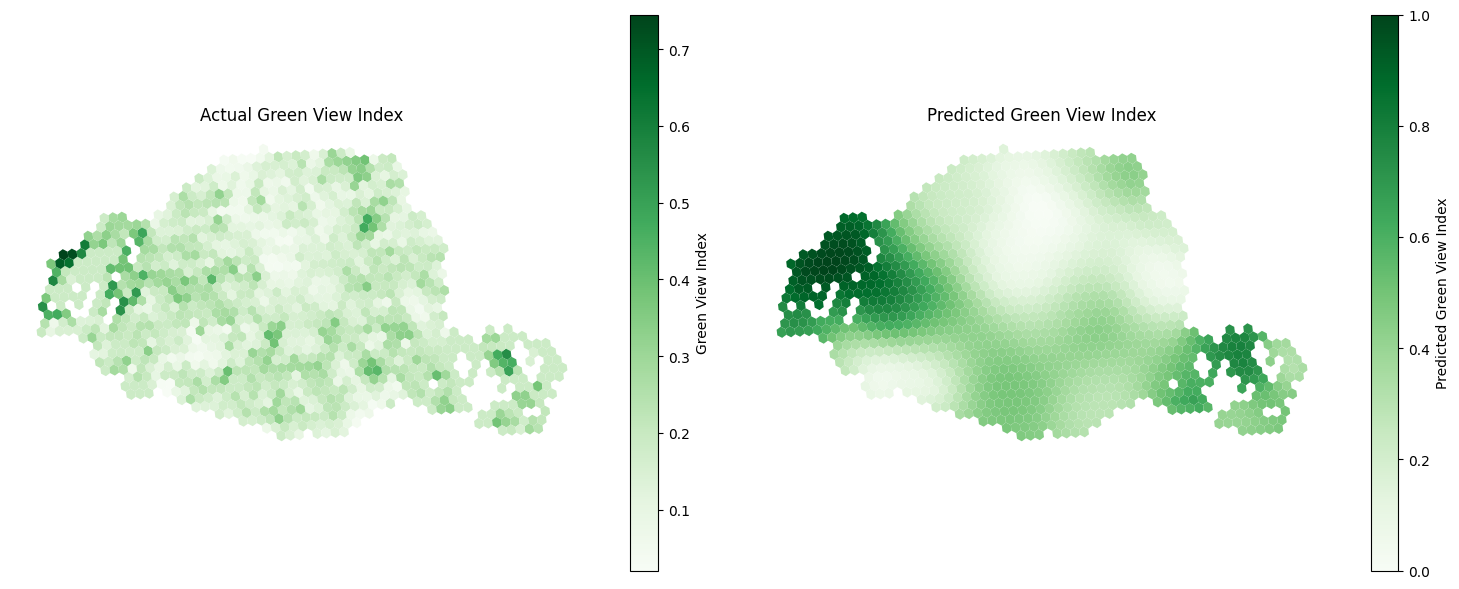

In [148]:
# load the best model
# Load best model for final evaluation
model.load_state_dict(torch.load('best_models_paris/best_hex_model.pth'))
test_loss = evaluate(BasicData, BasicData.test_mask)
print(f'Final Test Results - Loss: {test_loss:.4f}')

# Generate predictions for all nodes
model.eval()
with torch.no_grad():
    predictions = model(BasicData.x, BasicData.pe, BasicData.edge_index).squeeze().cpu().numpy()
#normalize predictions
scaler = MinMaxScaler()
predictions = scaler.fit_transform(predictions.reshape(-1, 1)).flatten()
# Add predictions back to the geodataframe for visualization
h3_nodes['predicted_green_view_performer'] = predictions
# Visualize results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# Actual Green View Index
h3_nodes.plot(column='Green View', cmap='Greens', markersize=2,
                     legend=True, ax=ax1, legend_kwds={'label': "Green View Index"})
ax1.set_title('Actual Green View Index')
ax1.set_axis_off()
# Predicted Green View Index
h3_nodes.plot(column='predicted_green_view_performer', cmap='Greens', markersize=2,
                     legend=True, ax=ax2, legend_kwds={'label': "Predicted Green View Index"})
ax2.set_title('Predicted Green View Index')
ax2.set_axis_off()
plt.tight_layout()
plt.show()

h3_nodes.drop(columns=['predicted_green_view_performer'], inplace=True)

### Attention

In [76]:
attention_scores = model.get_performer_attention(BasicData.x, BasicData.pe, BasicData.edge_index, layer_idx=1)
attention_scores = attention_scores.squeeze(0)  # Remove batch dimension
attention_scores.shape

torch.Size([4, 1228, 1228])

In [83]:
from shapely.geometry import LineString

# Select a specific attention head to analyze (out of 4 heads)
head_idx = 3  # Change to analyze different heads
head_attn = attention_scores[head_idx].cpu().detach().numpy()  # Shape: [nodes, nodes]

# Define how many top pairs to select
top_k = 500  # Adjust as needed

# Flatten the attention matrix and find top-k indices
flattened_attn = head_attn.flatten()
top_k_flat_indices = np.argsort(flattened_attn)[-top_k:][::-1]  # Get indices of top-k values

# Convert flat indices back to 2D indices (source, target)
num_nodes = head_attn.shape[0]
source_nodes = top_k_flat_indices // num_nodes
target_nodes = top_k_flat_indices % num_nodes
attn_values = flattened_attn[top_k_flat_indices]

# Create list of (source, target, attention) tuples
high_attention_pairs = list(zip(source_nodes, target_nodes, attn_values))

# Print statistics and top pairs
print(f"Top {top_k} attention pairs for head {head_idx}:")
print(f"Attention range: {attn_values.min():.8f} to {attn_values.max():.8f}")

for idx, (i, j, att) in enumerate(high_attention_pairs[:10]):  # Show first 10
    print(f"{idx+1}. Source node {i} → Target node {j}: Attention = {att:.6f}")

# Get a mapping from indices to h3 IDs
reverse_mapping = {idx: h3_id for h3_id, idx in node_mapping.items()}

# Create edge geometries for visualization
edge_geometries = []
edge_attrs = []  # To store attributes

# Create LineString geometries for each pair
for i, j, att in high_attention_pairs:
    source_h3_id = reverse_mapping[i]
    target_h3_id = reverse_mapping[j]
    
    source_point = h3_nodes.loc[source_h3_id, 'geometry'].centroid
    target_point = h3_nodes.loc[target_h3_id, 'geometry'].centroid

    
    # Create a LineString between the two centroids
    line = LineString([source_point, target_point])
    
    # Store geometry and attributes
    edge_geometries.append(line)
    edge_attrs.append({
        'source': source_h3_id, 
        'target': target_h3_id, 
        'attention': float(att)
    })



# Create a GeoDataFrame with attributes
high_attention_edges = gpd.GeoDataFrame(edge_attrs, geometry=edge_geometries, crs=h3_nodes.crs)

#save all nodes that are in the high_attention_edges
high_attention_nodes = set(high_attention_edges['source']).union(set(high_attention_edges['target']))
#save the nodes in a geodataframe
high_attention_nodes_gdf = h3_nodes[h3_nodes.index.isin(high_attention_nodes)]


Top 500 attention pairs for head 3:
Attention range: 0.00279289 to 0.00301029
1. Source node 938 → Target node 607: Attention = 0.003010
2. Source node 938 → Target node 597: Attention = 0.003008
3. Source node 942 → Target node 607: Attention = 0.003006
4. Source node 938 → Target node 595: Attention = 0.003005
5. Source node 1023 → Target node 607: Attention = 0.002999
6. Source node 938 → Target node 594: Attention = 0.002999
7. Source node 942 → Target node 597: Attention = 0.002995
8. Source node 1023 → Target node 597: Attention = 0.002991
9. Source node 1027 → Target node 607: Attention = 0.002991
10. Source node 1023 → Target node 595: Attention = 0.002991


/var/folders/2g/xkdpgwks0kzg848hbvw_8h1m0000gn/T/ipykernel_41563/561410942.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  xlim = (h3_nodes.geometry.centroid.x.min(), h3_nodes.geometry.centroid.x.max())
/var/folders/2g/xkdpgwks0kzg848hbvw_8h1m0000gn/T/ipykernel_41563/561410942.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ylim = (h3_nodes.geometry.centroid.y.min(), h3_nodes.geometry.centroid.y.max())


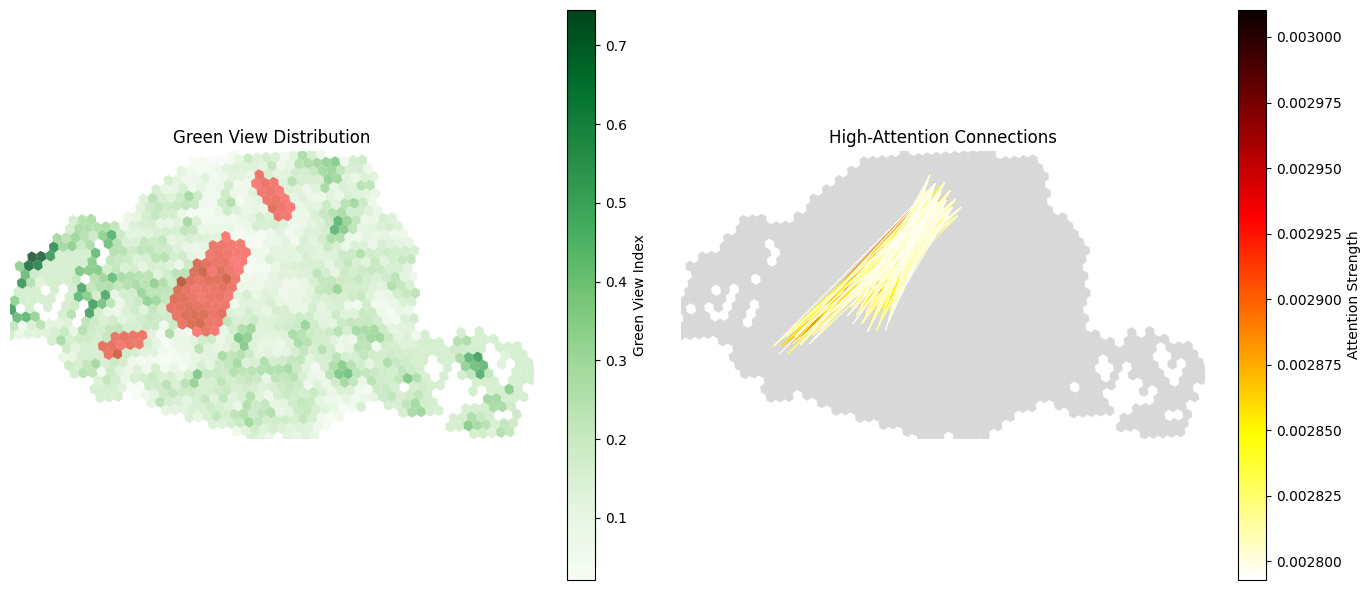

In [84]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left plot - Hexagon nodes colored by Green View
h3_nodes.plot(column='Green View', cmap='Greens', ax=ax1, linewidth=0.5, alpha=0.8, zorder=1, legend=True, 
              legend_kwds={'label': "Green View Index"})
high_attention_nodes_gdf.plot(ax=ax1, color='red', markersize=5, zorder=2, alpha=0.5)
ax1.set_title('Green View Distribution')
ax1.set_axis_off()

# Right plot - High-attention edges
h3_nodes.plot(ax=ax2, linewidth=0.5, alpha=0.3, color='gray', zorder=1)
# Plot high-attention edges
high_attention_edges.plot(ax=ax2, column='attention', cmap='hot_r', linewidth=0.8, 
                         legend=True, zorder=2, legend_kwds={'label': "Attention Strength"})
ax2.set_title('High-Attention Connections')
ax2.set_axis_off()

# Set consistent limits for both plots
xlim = (h3_nodes.geometry.centroid.x.min(), h3_nodes.geometry.centroid.x.max())
ylim = (h3_nodes.geometry.centroid.y.min(), h3_nodes.geometry.centroid.y.max())
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax2.set_xlim(xlim)
ax2.set_ylim(ylim)

plt.tight_layout()
plt.show()

I now have a way to retrieve and study attentions of any layer and any head

In [128]:
# distribution of the attention values
attention_weights_layer0 = model.get_performer_attention(BasicData.x, BasicData.pe, BasicData.edge_index, layer_idx=0)
attention_weights_layer0 = attention_weights_layer0.squeeze(0).detach().cpu().numpy()

attention_weights_layer1 = model.get_performer_attention(BasicData.x, BasicData.pe, BasicData.edge_index, layer_idx=1)
attention_weights_layer1 = attention_weights_layer1.squeeze(0).detach().cpu().numpy()

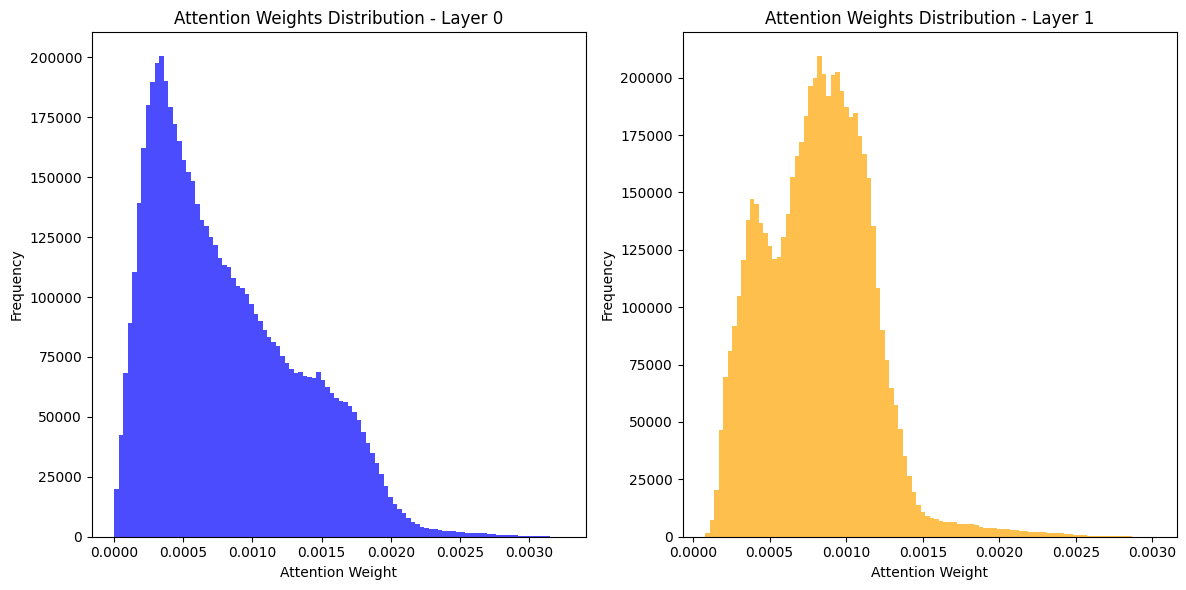

In [ ]:
# plot the distribution of the attention weights
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(attention_weights_layer0.flatten(), bins=100, color='blue', alpha=0.7)
plt.title('Attention Weights Distribution - Layer 0')
plt.xlabel('Attention Weight')
plt.ylabel('Frequency')
plt.subplot(1, 2, 2)
plt.hist(attention_weights_layer1.flatten(), bins=100, color='orange', alpha=0.7)
plt.title('Attention Weights Distribution - Layer 1')
plt.xlabel('Attention Weight')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

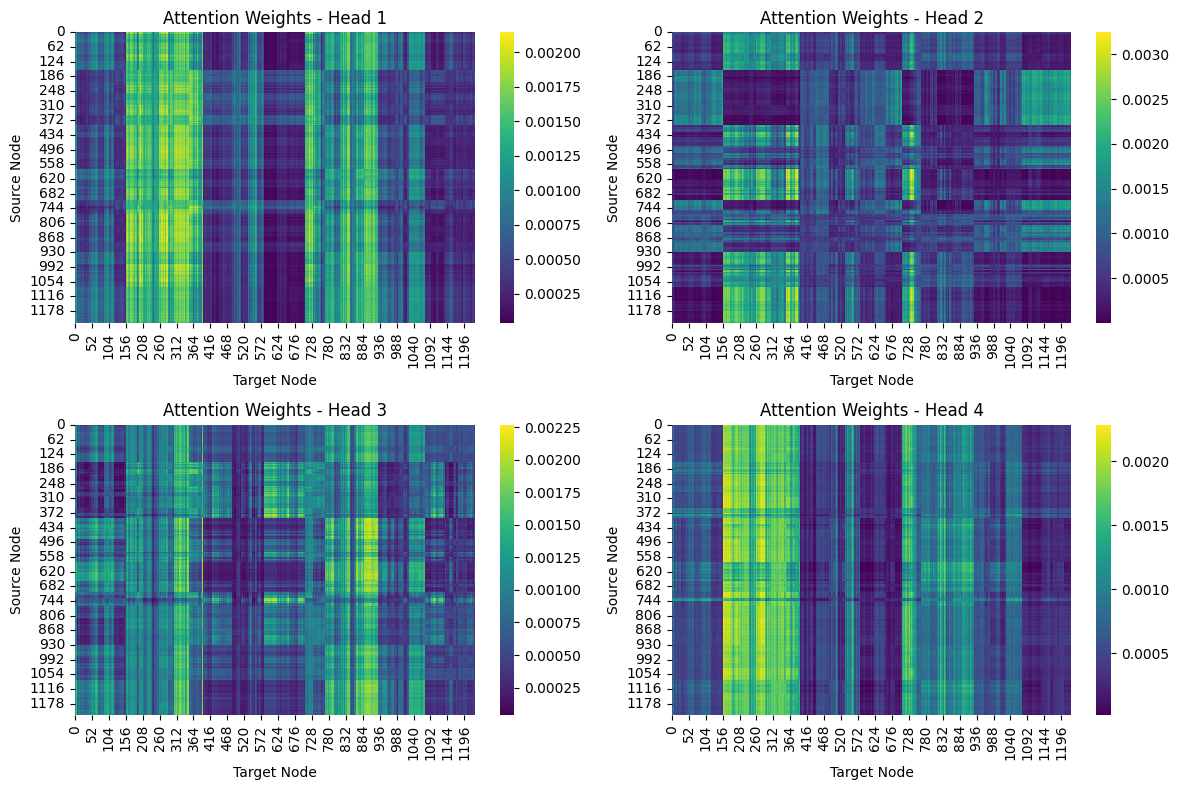

In [106]:
# heat maps of the attention weights
import seaborn as sns
# all 4 heads
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i in range(4):
    ax = axes[i // 2, i % 2]
    sns.heatmap(attention_weights_layer0[i], ax=ax, cmap='viridis', cbar=True)
    ax.set_title(f'Attention Weights - Head {i+1}')
    ax.set_xlabel('Target Node')
    ax.set_ylabel('Source Node')
plt.tight_layout()
plt.show()

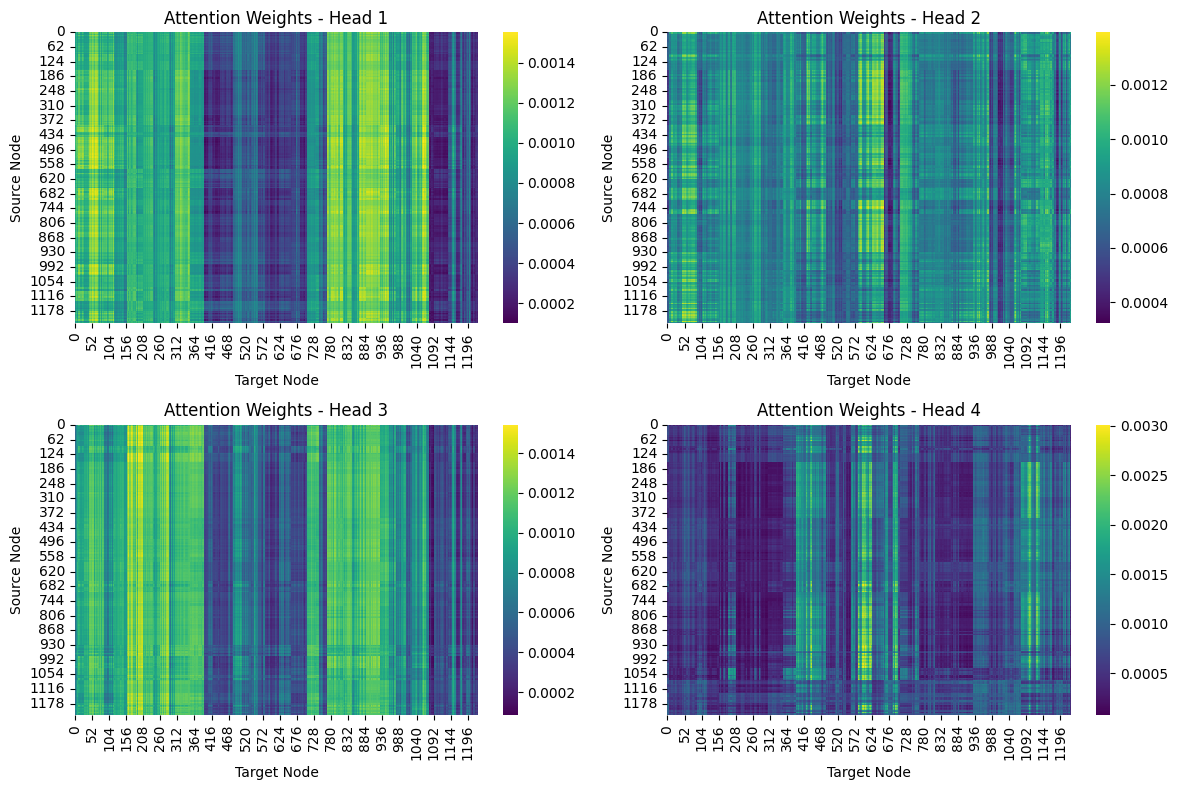

In [ ]:
# heat maps of the attention weights
import seaborn as sns
# all 4 heads
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i in range(4):
    ax = axes[i // 2, i % 2]
    sns.heatmap(attention_weights_layer1[i], ax=ax, cmap='viridis', cbar=True)
    ax.set_title(f'Attention Weights - Head {i+1}')
    ax.set_xlabel('Target Node')
    ax.set_ylabel('Source Node')
plt.tight_layout()
plt.show()

In [137]:
attention_edge_lengths_layer0 = {}
N = attention_weights_layer0[0].shape[0]

for head in range(4):
    attention_edge_lengths_layer0[head] = []
    for i in range(N):
        for j in range(N):
            if i == j:
                continue    # skip self-loops
            # Get the attention value at position (i,j) of head 0
            att_value = attention_weights_layer0[head][i, j]
            
            # Get the corresponding H3 IDs
            source_h3_id = reverse_mapping[i]
            target_h3_id = reverse_mapping[j]
            source_point = h3_nodes.loc[source_h3_id, 'geometry'].centroid
            target_point = h3_nodes.loc[target_h3_id, 'geometry'].centroid
            
            # Calculate the length of the edge
            length = source_point.distance(target_point)
            attention_edge_lengths_layer0[head].append((i, j, att_value, length))
# Convert to DataFrame for easier manipulation
attention_edge_lengths_layer0_df = {}
for head, values in attention_edge_lengths_layer0.items():
    attention_edge_lengths_layer0_df[head] = pd.DataFrame(values, columns=['source', 'target', 'attention', 'length'])

In [129]:
attention_edge_lengths_layer1 = {}
for head in range(4):
    attention_edge_lengths_layer1[head] = []
    for i in range(N):
        for j in range(N):
            if i == j:
                continue    # skip self-loops
            # Get the attention value at position (i,j) of head 0
            att_value = attention_weights_layer1[head][i, j]
            
            # Get the corresponding H3 IDs
            source_h3_id = reverse_mapping[i]
            target_h3_id = reverse_mapping[j]
            source_point = h3_nodes.loc[source_h3_id, 'geometry'].centroid
            target_point = h3_nodes.loc[target_h3_id, 'geometry'].centroid
            
            # Calculate the length of the edge
            length = source_point.distance(target_point)
            attention_edge_lengths_layer1[head].append((i, j, att_value, length))
# Convert to DataFrame for easier manipulation
attention_edge_lengths_layer1_df = {}
for head, values in attention_edge_lengths_layer1.items():
    attention_edge_lengths_layer1_df[head] = pd.DataFrame(values, columns=['source', 'target', 'attention', 'length'])

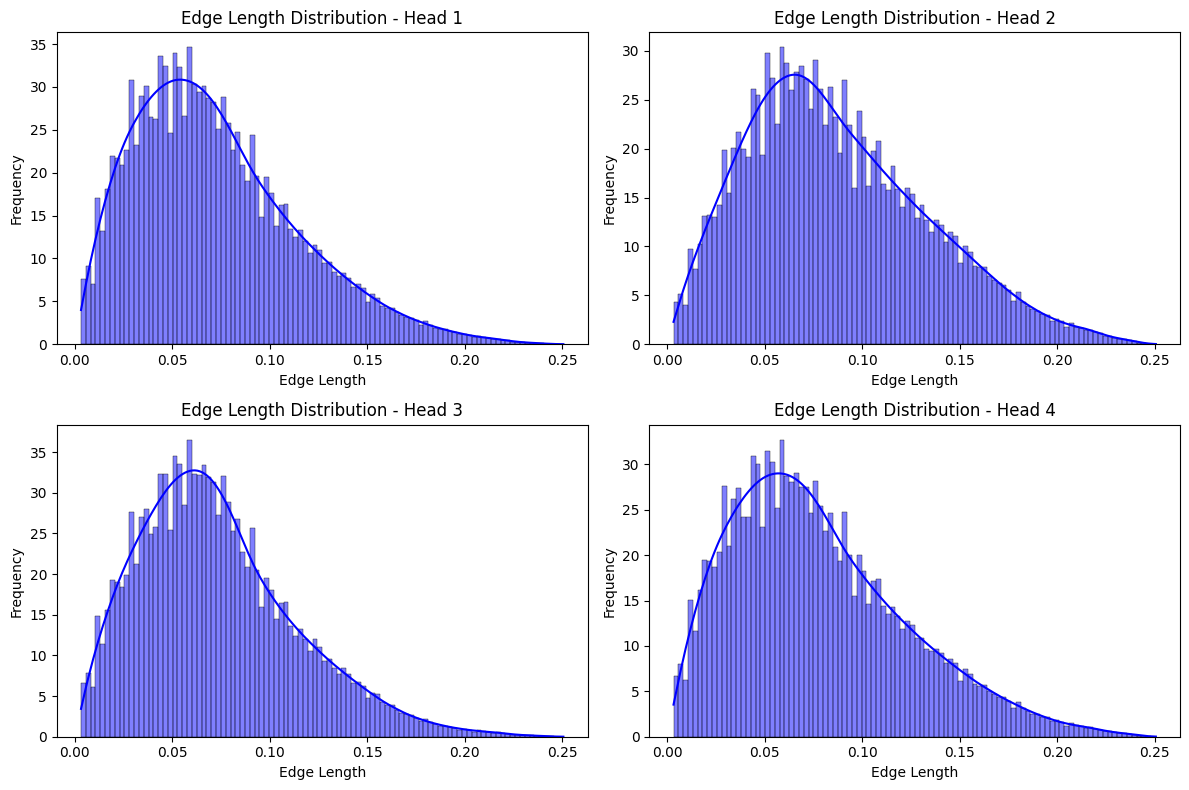

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i in range(4):
    ax = axes[i // 2, i % 2]
    # Use the data parameter and specify column names
    sns.histplot(
        data=attention_edge_lengths_layer0_df[i], 
        x='length',
        weights='attention',
        bins=100, 
        ax=ax, 
        color='blue', 
        kde=True
    )
    ax.set_title(f'Edge Length Distribution - Head {i+1}')
    ax.set_xlabel('Edge Length')
    ax.set_ylabel('Weighted Frequency')
plt.tight_layout()
plt.show()

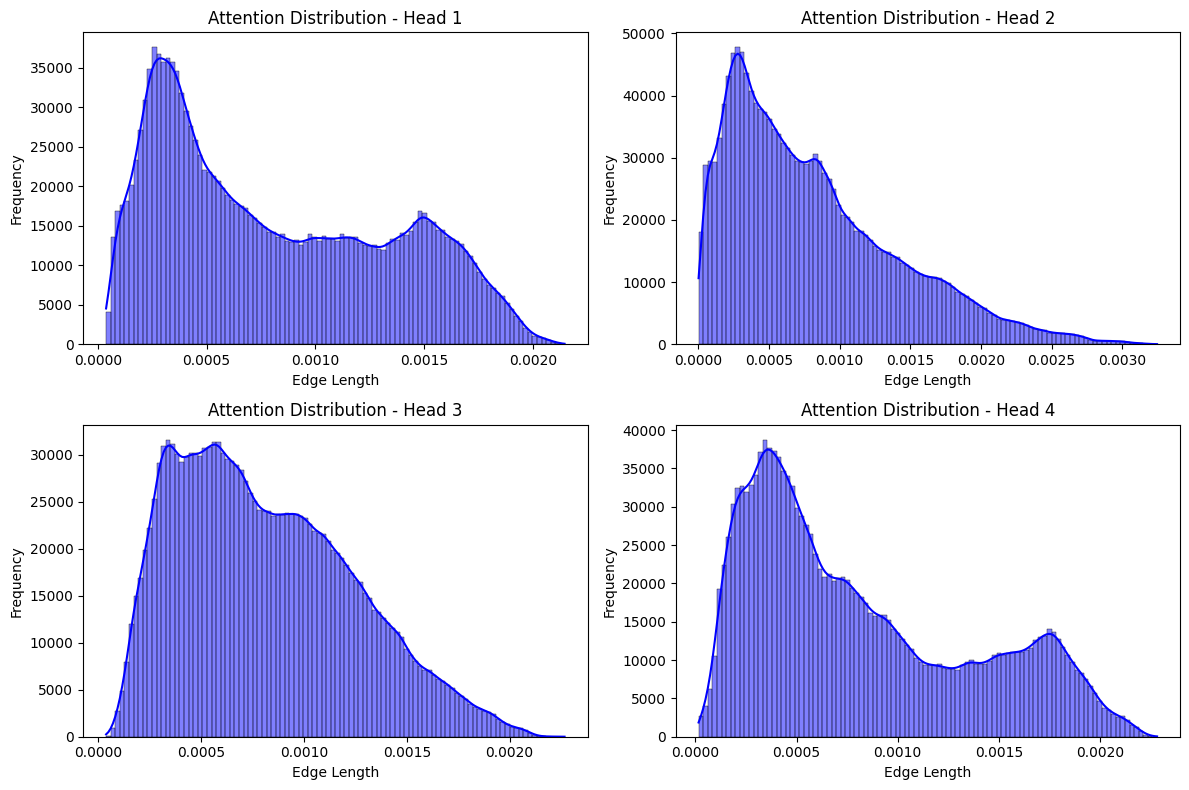

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i in range(4):
    ax = axes[i // 2, i % 2]
    sns.histplot(attention_edge_lengths_layer0_df[i]['attention'], bins=100, ax=ax, color='blue', kde=True)
    ax.set_title(f'Attention Distribution - Head {i+1}')
    ax.set_xlabel('Edge Length')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

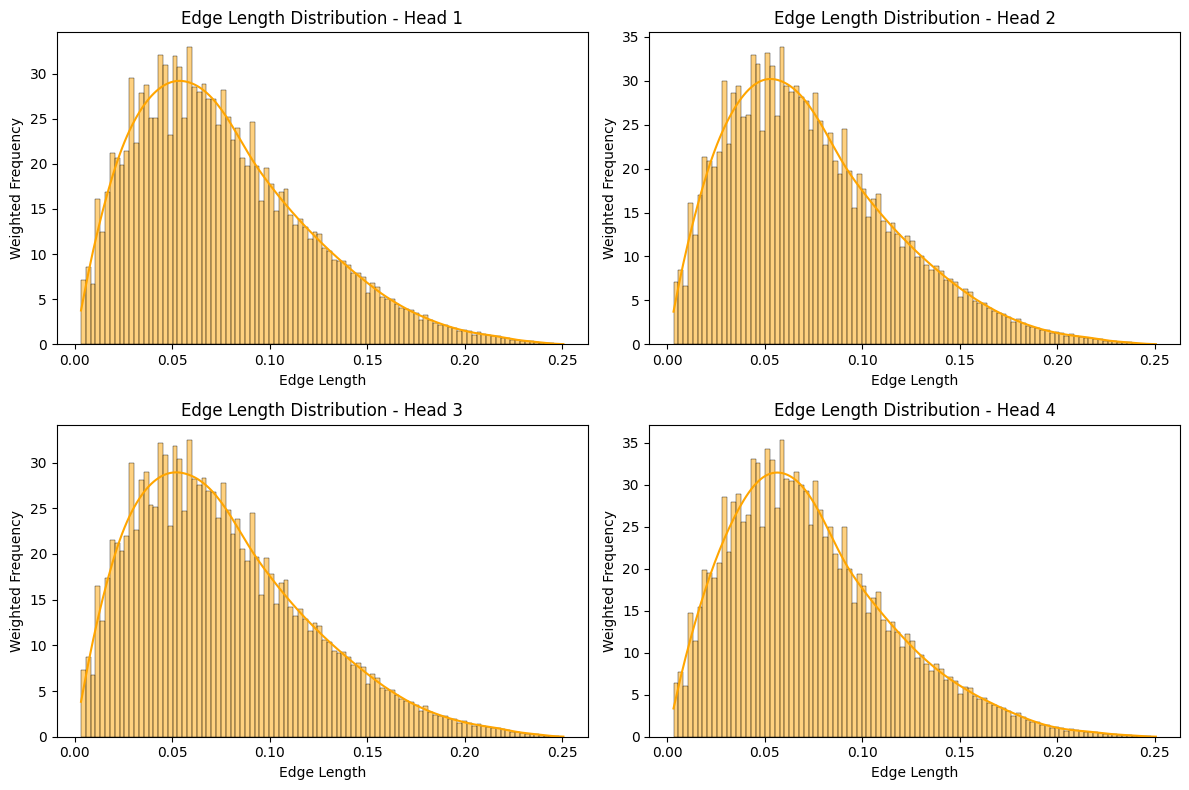

In [141]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i in range(4):
    ax = axes[i // 2, i % 2]
    # Use the data parameter and specify column names
    sns.histplot(
        data=attention_edge_lengths_layer1_df[i], 
        x='length',
        weights='attention',
        bins=100, 
        ax=ax, 
        color='orange', 
        kde=True
    )
    ax.set_title(f'Edge Length Distribution - Head {i+1}')
    ax.set_xlabel('Edge Length')
    ax.set_ylabel('Weighted Frequency')
plt.tight_layout()
plt.show()

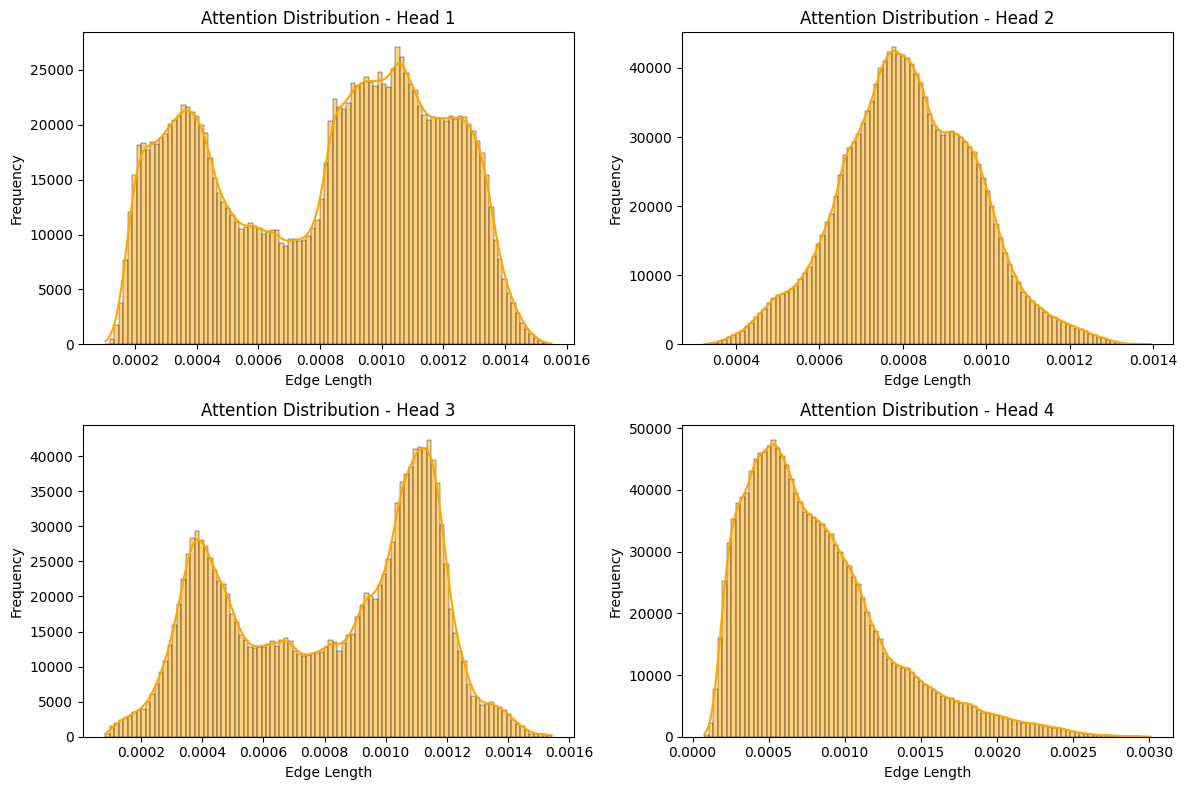

In [132]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i in range(4):
    ax = axes[i // 2, i % 2]
    sns.histplot(attention_edge_lengths_layer1_df[i]['attention'], bins=100, ax=ax, color='orange', kde=True)
    ax.set_title(f'Attention Distribution - Head {i+1}')
    ax.set_xlabel('Edge Length')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
# Average the attention with the distance
mean_attentions_layer0 = {}
for head in range(4):
    mean_attentions_layer0[head] = (attention_edge_lengths_layer0_df[head]['attention']*attention_edge_lengths_layer0_df[head]['length']).sum() / attention_edge_lengths_layer0_df[head]['length'].sum()
    print(f"Mean attention for head {head}: {mean_attentions_layer0[head]:.4f}")

Mean attention for head 0: 0.0008
Mean attention for head 1: 0.0010
Mean attention for head 2: 0.0008
Mean attention for head 3: 0.0009


In [143]:
mean_attentions_layer1 = {}
for head in range(4):
    mean_attentions_layer1[head] = (attention_edge_lengths_layer1_df[head]['attention']*attention_edge_lengths_layer1_df[head]['length']).sum() / attention_edge_lengths_layer1_df[head]['length'].sum()
    print(f"Mean attention for head {head}: {mean_attentions_layer1[head]:.4f}")

Mean attention for head 0: 0.0008
Mean attention for head 1: 0.0008
Mean attention for head 2: 0.0008
Mean attention for head 3: 0.0008


## Data and model with all features
Now I will create a dataset with all the features, and I will train the model again.
Let's see if there are clear differences

In [149]:
completeHexes = h3_nodes.copy()
completeHexes = completeHexes.drop(columns=['geometry', 'Green View'])
completeHexes.head()

,osmid,x,y,Node Density,Street Length,Degree,Clustering,Clustering (Weighted),Closeness Centrality,Betweenness Centrality,...,Commercial,Entertainment,Food,Healthcare,Institutional,Recreational,Social,Sky View,Building View,Road View
h3_09,,,,,,,,,,,,,,,,,,,,,
891fb460d83ffff,3.538013e+09,2.271580,48.827032,35.560000,4607.870271,2.360000,0.0000,0.000000,0.020330,0.000400,...,5.680000,0.040000,6.480000,0.0,0.200000,6.760000,0.200000,0.151214,0.251172,0.172528
891fb460d87ffff,1.943869e+09,2.275902,48.827210,31.812500,3992.693797,2.562500,0.0625,0.000698,0.021747,0.001017,...,4.625000,0.000000,6.750000,0.0,0.000000,8.375000,0.000000,0.151214,0.251172,0.172528
891fb460d93ffff,4.903774e+09,2.268915,48.829594,26.466667,4718.117299,2.400000,0.0000,0.000000,0.019602,0.000146,...,4.866667,1.666667,5.733333,0.0,3.733333,6.000000,0.066667,0.151214,0.251172,0.172528
891fb460d97ffff,4.816848e+08,2.273237,48.829773,21.333333,3561.154014,1.666667,0.0000,0.000000,0.020608,0.000278,...,5.666667,0.333333,6.333333,0.0,0.000000,7.000000,0.000000,0.151214,0.251172,0.172528
891fb460d9bffff,6.665745e+09,2.267258,48.826853,31.333333,4092.815318,2.428571,0.0000,0.000000,0.020462,0.000486,...,7.380952,1.142857,6.904762,0.0,3.857143,7.142857,1.000000,0.151214,0.251172,0.172528


In [151]:
device = 'cpu' 
print(device)
y = h3_nodes['Green View'].values
X = completeHexes.values
X = np.array(X)
scaler =  StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'X_scaled shape: {X_scaled.shape}')
# edge_index is already created, it can be re-used

cpu
X_scaled shape: (1228, 39)


In [152]:
# we have x, y and edge_index, now we need to create the Data object

transform = T.AddLaplacianEigenvectorPE(k = 20, attr_name= 'pe')
CompleteData = Data(x = torch.FloatTensor(X_scaled), y = torch.FloatTensor(y), edge_index = edge_index )
CompleteData = transform(CompleteData)

# Split data into train/val/test sets (70%/15%/15%)
np.random.seed(10)
n_nodes = CompleteData.num_nodes
indices = np.random.permutation(n_nodes)

train_idx = indices[:int(0.7 * n_nodes)]
print(len(train_idx)) #debug
val_idx = indices[int(0.7 * n_nodes):int(0.85 * n_nodes)]
print(len(val_idx)) #debug
test_idx = indices[int(0.85 * n_nodes):]
print(len(test_idx)) #debug

# Create masks
train_mask = torch.zeros(n_nodes, dtype=torch.bool)
val_mask = torch.zeros(n_nodes, dtype=torch.bool)
test_mask = torch.zeros(n_nodes, dtype=torch.bool)


train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True
        
CompleteData.train_mask = train_mask    #size is still all nodes but only True for train nodes
CompleteData.val_mask = val_mask
CompleteData.test_mask = test_mask

CompleteData.to(device)

859
184
185


Data(x=[1228, 39], edge_index=[2, 6844], y=[1228], pe=[1228, 20], train_mask=[1228], val_mask=[1228], test_mask=[1228])

Once again, data is done, model actually is already been defined, so let's call it and train it.


In [157]:
#model inizialization
model = HybridModelv2(
    in_channels=CompleteData.num_features,
    pe_input_dim=CompleteData.pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_layers=2,
    dropout=0.4,
    combine_method='sum'
)
model.to(device)

HybridModelv2(
  (node_emb): Linear(in_features=39, out_features=48, bias=True)
  (pe_lin): Linear(in_features=20, out_features=16, bias=True)
  (pe_norm): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layers): ModuleList(
    (0-1): 2 x ModuleDict(
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attention): PerformerAttention(heads=4, head_channels=16 kernel=ReLU())
      (gat): GATv2Conv(64, 16, heads=4)
      (combine): Identity()
      (ffn): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): Dropout(p=0.4, inplace=False)
        (2): ReLU()
        (3): Linear(in_features=128, out_features=64, bias=True)
      )
    )
  )
  (output_layer): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

### Training

In [158]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)
# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []
print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train(CompleteData)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(CompleteData, CompleteData.val_mask)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_models_paris/best_hex_model_complete.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        
        
    
    # Print progress
    if epoch % 10 == 0:
        test_loss  = evaluate(CompleteData, CompleteData.test_mask)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, ')
        
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 0.0112, Val Loss: 0.0067, Test Loss: 0.0072, 
Epoch: 020, Train Loss: 0.0096, Val Loss: 0.0071, Test Loss: 0.0076, 
Epoch: 030, Train Loss: 0.0085, Val Loss: 0.0056, Test Loss: 0.0063, 
Epoch: 040, Train Loss: 0.0082, Val Loss: 0.0055, Test Loss: 0.0062, 
Epoch: 050, Train Loss: 0.0073, Val Loss: 0.0050, Test Loss: 0.0058, 
Epoch: 060, Train Loss: 0.0070, Val Loss: 0.0050, Test Loss: 0.0057, 
Epoch: 070, Train Loss: 0.0060, Val Loss: 0.0046, Test Loss: 0.0053, 
Epoch: 080, Train Loss: 0.0058, Val Loss: 0.0043, Test Loss: 0.0050, 
Epoch: 090, Train Loss: 0.0055, Val Loss: 0.0039, Test Loss: 0.0048, 
Epoch: 100, Train Loss: 0.0051, Val Loss: 0.0034, Test Loss: 0.0048, 
Epoch: 110, Train Loss: 0.0038, Val Loss: 0.0035, Test Loss: 0.0047, 
Epoch: 120, Train Loss: 0.0044, Val Loss: 0.0036, Test Loss: 0.0050, 
Epoch: 130, Train Loss: 0.0040, Val Loss: 0.0031, Test Loss: 0.0046, 
Epoch: 140, Train Loss: 0.0038, Val Loss: 0.0030, Test Loss: 0

### Results

Final Test Results - Loss: 0.0035


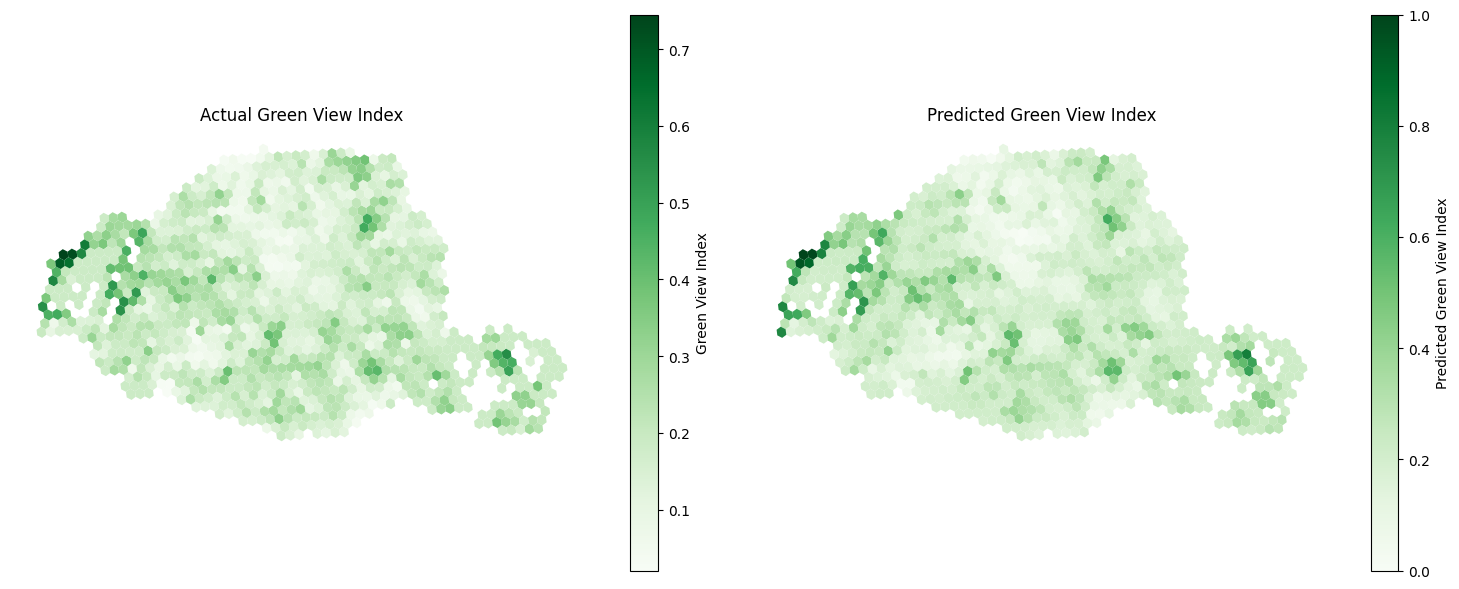

In [159]:
# load the best model
# Load best model for final evaluation
model.load_state_dict(torch.load('best_models_paris/best_hex_model_complete.pth'))
test_loss = evaluate(CompleteData, CompleteData.test_mask)
print(f'Final Test Results - Loss: {test_loss:.4f}')

# Generate predictions for all nodes
model.eval()
with torch.no_grad():
    predictions = model(CompleteData.x, CompleteData.pe, CompleteData.edge_index).squeeze().cpu().numpy()
#normalize predictions
scaler = MinMaxScaler()
predictions = scaler.fit_transform(predictions.reshape(-1, 1)).flatten()
# Add predictions back to the geodataframe for visualization
h3_nodes['predicted_green_view_performer'] = predictions
# Visualize results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# Actual Green View Index
h3_nodes.plot(column='Green View', cmap='Greens', markersize=2,
                     legend=True, ax=ax1, legend_kwds={'label': "Green View Index"})
ax1.set_title('Actual Green View Index')
ax1.set_axis_off()
# Predicted Green View Index
h3_nodes.plot(column='predicted_green_view_performer', cmap='Greens', markersize=2,
                     legend=True, ax=ax2, legend_kwds={'label': "Predicted Green View Index"})
ax2.set_title('Predicted Green View Index')
ax2.set_axis_off()
plt.tight_layout()
plt.show()

h3_nodes.drop(columns=['predicted_green_view_performer'], inplace=True)

### Attention

In [178]:
attention_scores = model.get_performer_attention(CompleteData.x, CompleteData.pe, CompleteData.edge_index, layer_idx=1)
attention_scores = attention_scores.squeeze(0)  # Remove batch dimension
attention_scores.shape

torch.Size([4, 1228, 1228])

In [185]:
from shapely.geometry import LineString

# Select a specific attention head to analyze (out of 4 heads)
head_idx = 0  # Change to analyze different heads
head_attn = attention_scores[head_idx].cpu().detach().numpy()  # Shape: [nodes, nodes]

# Define how many top pairs to select
top_k = 100  # Adjust as needed

# Flatten the attention matrix and find top-k indices
flattened_attn = head_attn.flatten()
top_k_flat_indices = np.argsort(flattened_attn)[-top_k:][::-1]  # Get indices of top-k values

# Convert flat indices back to 2D indices (source, target)
num_nodes = head_attn.shape[0]
source_nodes = top_k_flat_indices // num_nodes
target_nodes = top_k_flat_indices % num_nodes
attn_values = flattened_attn[top_k_flat_indices]

# Create list of (source, target, attention) tuples
high_attention_pairs = list(zip(source_nodes, target_nodes, attn_values))

# Print statistics and top pairs
print(f"Top {top_k} attention pairs for head {head_idx}:")
print(f"Attention range: {attn_values.min():.8f} to {attn_values.max():.8f}")

for idx, (i, j, att) in enumerate(high_attention_pairs[:10]):  # Show first 10
    print(f"{idx+1}. Source node {i} → Target node {j}: Attention = {att:.6f}")

# Get a mapping from indices to h3 IDs
reverse_mapping = {idx: h3_id for h3_id, idx in node_mapping.items()}

# Create edge geometries for visualization
edge_geometries = []
edge_attrs = []  # To store attributes

# Create LineString geometries for each pair
for i, j, att in high_attention_pairs:
    source_h3_id = reverse_mapping[i]
    target_h3_id = reverse_mapping[j]
    
    source_point = h3_nodes.loc[source_h3_id, 'geometry'].centroid
    target_point = h3_nodes.loc[target_h3_id, 'geometry'].centroid

    
    # Create a LineString between the two centroids
    line = LineString([source_point, target_point])
    
    # Store geometry and attributes
    edge_geometries.append(line)
    edge_attrs.append({
        'source': source_h3_id, 
        'target': target_h3_id, 
        'attention': float(att)
    })



# Create a GeoDataFrame with attributes
high_attention_edges = gpd.GeoDataFrame(edge_attrs, geometry=edge_geometries, crs=h3_nodes.crs)

#save all nodes that are in the high_attention_edges
high_attention_nodes = set(high_attention_edges['source']).union(set(high_attention_edges['target']))
#save the nodes in a geodataframe
high_attention_nodes_gdf = h3_nodes[h3_nodes.index.isin(high_attention_nodes)]

Top 100 attention pairs for head 0:
Attention range: 0.00204262 to 0.00235861
1. Source node 92 → Target node 72: Attention = 0.002359
2. Source node 1202 → Target node 377: Attention = 0.002261
3. Source node 170 → Target node 72: Attention = 0.002254
4. Source node 92 → Target node 134: Attention = 0.002247
5. Source node 1025 → Target node 374: Attention = 0.002242
6. Source node 90 → Target node 72: Attention = 0.002219
7. Source node 92 → Target node 1142: Attention = 0.002214
8. Source node 984 → Target node 374: Attention = 0.002212
9. Source node 109 → Target node 72: Attention = 0.002211
10. Source node 1007 → Target node 215: Attention = 0.002203


/var/folders/2g/xkdpgwks0kzg848hbvw_8h1m0000gn/T/ipykernel_41563/561410942.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  xlim = (h3_nodes.geometry.centroid.x.min(), h3_nodes.geometry.centroid.x.max())
/var/folders/2g/xkdpgwks0kzg848hbvw_8h1m0000gn/T/ipykernel_41563/561410942.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ylim = (h3_nodes.geometry.centroid.y.min(), h3_nodes.geometry.centroid.y.max())


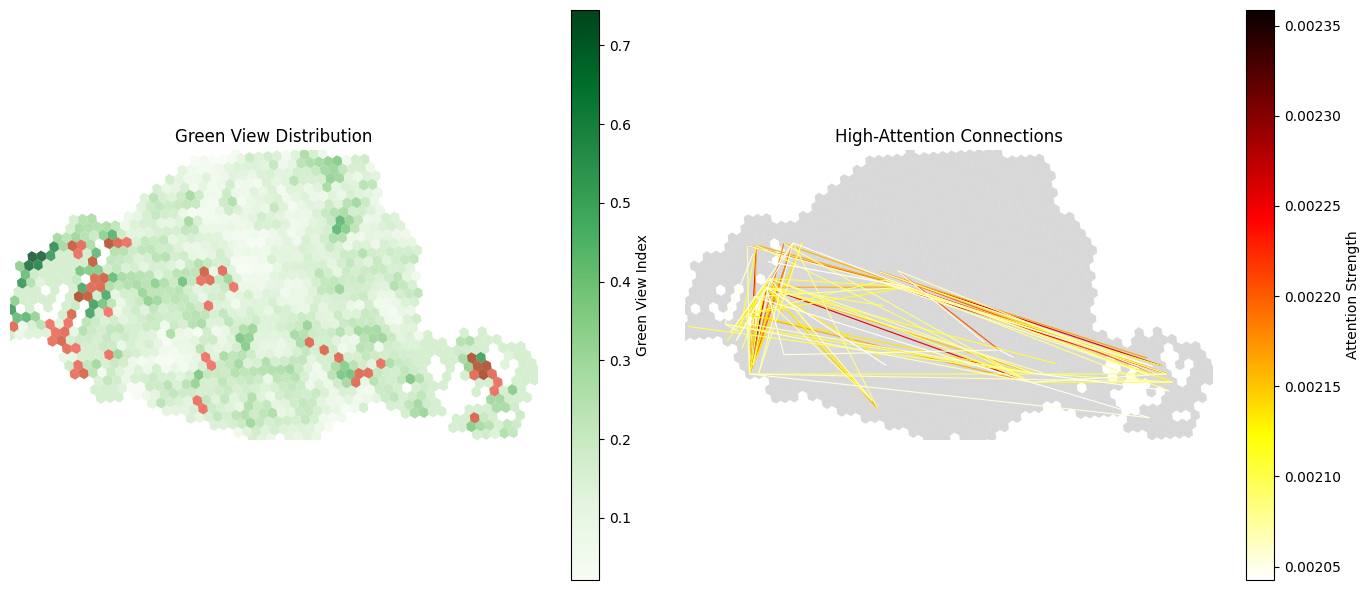

In [186]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left plot - Hexagon nodes colored by Green View
h3_nodes.plot(column='Green View', cmap='Greens', ax=ax1, linewidth=0.5, alpha=0.8, zorder=1, legend=True, 
              legend_kwds={'label': "Green View Index"})
high_attention_nodes_gdf.plot(ax=ax1, color='red', markersize=5, zorder=2, alpha=0.5)
ax1.set_title('Green View Distribution')
ax1.set_axis_off()

# Right plot - High-attention edges
h3_nodes.plot(ax=ax2, linewidth=0.5, alpha=0.3, color='gray', zorder=1)
# Plot high-attention edges
high_attention_edges.plot(ax=ax2, column='attention', cmap='hot_r', linewidth=0.8, 
                         legend=True, zorder=2, legend_kwds={'label': "Attention Strength"})
ax2.set_title('High-Attention Connections')
ax2.set_axis_off()

# Set consistent limits for both plots
xlim = (h3_nodes.geometry.centroid.x.min(), h3_nodes.geometry.centroid.x.max())
ylim = (h3_nodes.geometry.centroid.y.min(), h3_nodes.geometry.centroid.y.max())
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax2.set_xlim(xlim)
ax2.set_ylim(ylim)

plt.tight_layout()
plt.show()

In [188]:
# distribution of the attention values
attention_weights_layer0 = model.get_performer_attention(CompleteData.x, CompleteData.pe, CompleteData.edge_index, layer_idx=0)
attention_weights_layer0 = attention_weights_layer0.squeeze(0).detach().cpu().numpy()

attention_weights_layer1 = model.get_performer_attention(CompleteData.x, CompleteData.pe, CompleteData.edge_index, layer_idx=1)
attention_weights_layer1 = attention_weights_layer1.squeeze(0).detach().cpu().numpy()

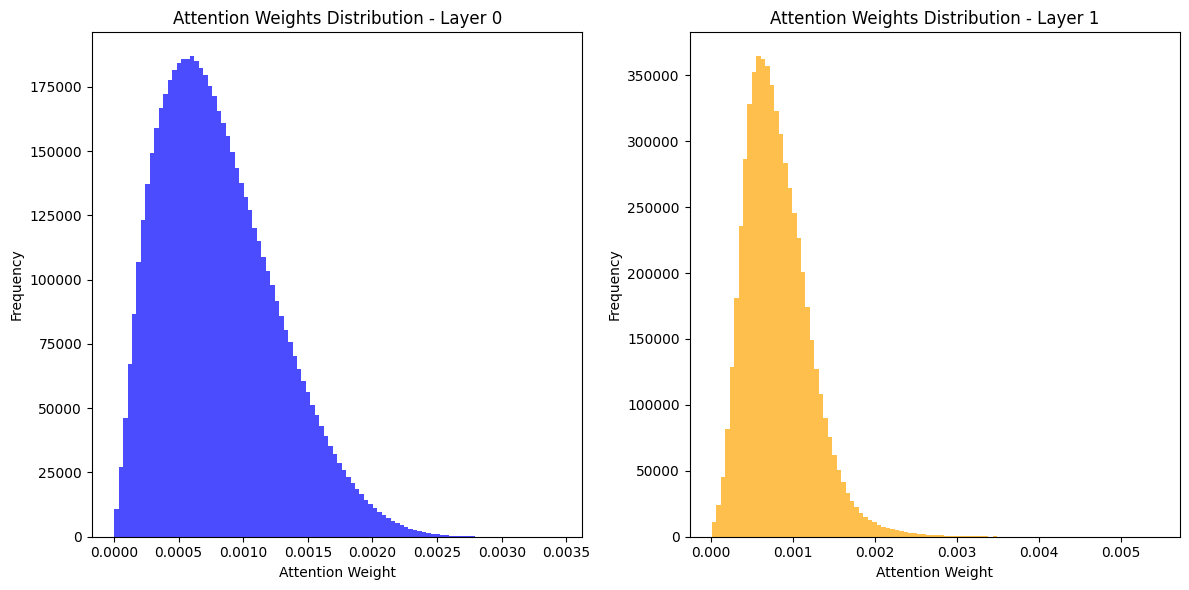

In [189]:
# plot the distribution of the attention weights
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(attention_weights_layer0.flatten(), bins=100, color='blue', alpha=0.7)
plt.title('Attention Weights Distribution - Layer 0')
plt.xlabel('Attention Weight')
plt.ylabel('Frequency')
plt.subplot(1, 2, 2)
plt.hist(attention_weights_layer1.flatten(), bins=100, color='orange', alpha=0.7)
plt.title('Attention Weights Distribution - Layer 1')
plt.xlabel('Attention Weight')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

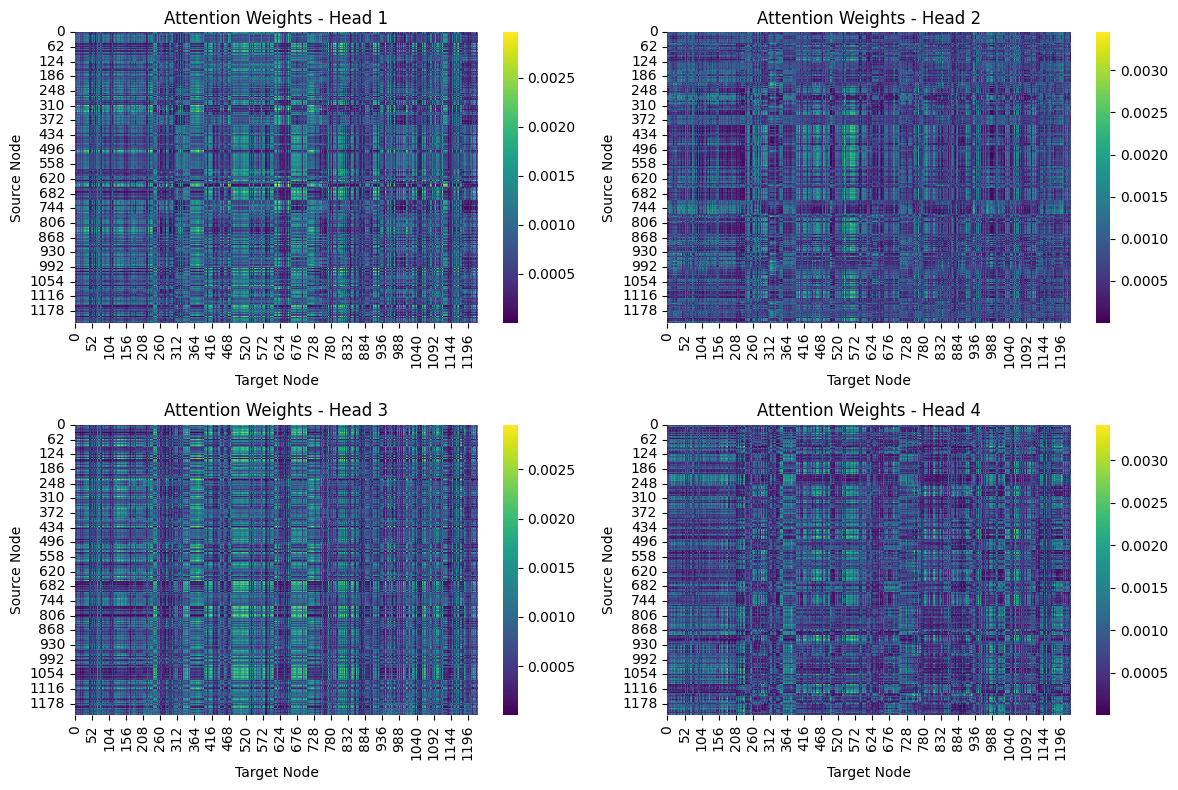

In [190]:
# heat maps of the attention weights
import seaborn as sns
# all 4 heads
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i in range(4):
    ax = axes[i // 2, i % 2]
    sns.heatmap(attention_weights_layer0[i], ax=ax, cmap='viridis', cbar=True)
    ax.set_title(f'Attention Weights - Head {i+1}')
    ax.set_xlabel('Target Node')
    ax.set_ylabel('Source Node')
plt.tight_layout()
plt.show()

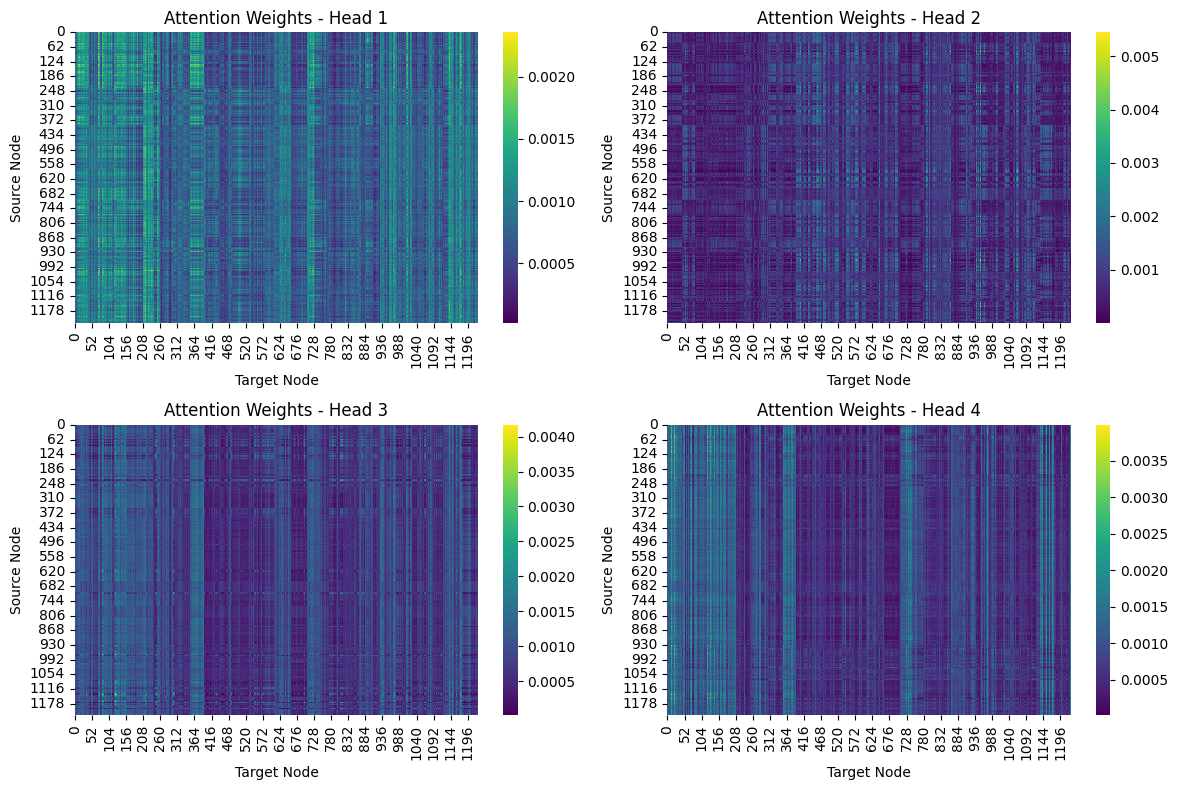

In [191]:
# heat maps of the attention weights
import seaborn as sns
# all 4 heads
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i in range(4):
    ax = axes[i // 2, i % 2]
    sns.heatmap(attention_weights_layer1[i], ax=ax, cmap='viridis', cbar=True)
    ax.set_title(f'Attention Weights - Head {i+1}')
    ax.set_xlabel('Target Node')
    ax.set_ylabel('Source Node')
plt.tight_layout()
plt.show()

In [192]:
attention_edge_lengths_layer0 = {}
N = attention_weights_layer0[0].shape[0]

for head in range(4):
    attention_edge_lengths_layer0[head] = []
    for i in range(N):
        for j in range(N):
            if i == j:
                continue    # skip self-loops
            # Get the attention value at position (i,j) of head 0
            att_value = attention_weights_layer0[head][i, j]
            
            # Get the corresponding H3 IDs
            source_h3_id = reverse_mapping[i]
            target_h3_id = reverse_mapping[j]
            source_point = h3_nodes.loc[source_h3_id, 'geometry'].centroid
            target_point = h3_nodes.loc[target_h3_id, 'geometry'].centroid
            
            # Calculate the length of the edge
            length = source_point.distance(target_point)
            attention_edge_lengths_layer0[head].append((i, j, att_value, length))
# Convert to DataFrame for easier manipulation
attention_edge_lengths_layer0_df = {}
for head, values in attention_edge_lengths_layer0.items():
    attention_edge_lengths_layer0_df[head] = pd.DataFrame(values, columns=['source', 'target', 'attention', 'length'])

In [193]:
attention_edge_lengths_layer1 = {}
for head in range(4):
    attention_edge_lengths_layer1[head] = []
    for i in range(N):
        for j in range(N):
            if i == j:
                continue    # skip self-loops
            # Get the attention value at position (i,j) of head 0
            att_value = attention_weights_layer1[head][i, j]
            
            # Get the corresponding H3 IDs
            source_h3_id = reverse_mapping[i]
            target_h3_id = reverse_mapping[j]
            source_point = h3_nodes.loc[source_h3_id, 'geometry'].centroid
            target_point = h3_nodes.loc[target_h3_id, 'geometry'].centroid
            
            # Calculate the length of the edge
            length = source_point.distance(target_point)
            attention_edge_lengths_layer1[head].append((i, j, att_value, length))
# Convert to DataFrame for easier manipulation
attention_edge_lengths_layer1_df = {}
for head, values in attention_edge_lengths_layer1.items():
    attention_edge_lengths_layer1_df[head] = pd.DataFrame(values, columns=['source', 'target', 'attention', 'length'])

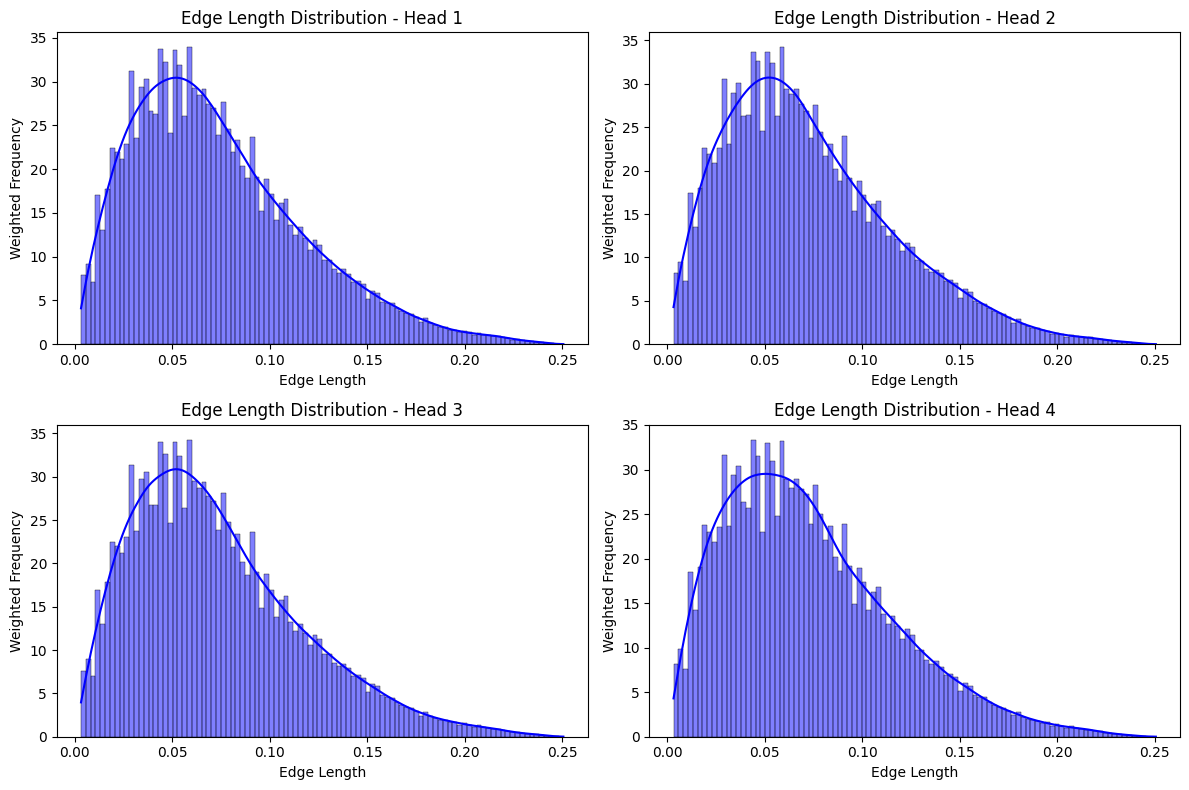

In [194]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i in range(4):
    ax = axes[i // 2, i % 2]
    # Use the data parameter and specify column names
    sns.histplot(
        data=attention_edge_lengths_layer0_df[i], 
        x='length',
        weights='attention',
        bins=100, 
        ax=ax, 
        color='blue', 
        kde=True
    )
    ax.set_title(f'Edge Length Distribution - Head {i+1}')
    ax.set_xlabel('Edge Length')
    ax.set_ylabel('Weighted Frequency')
plt.tight_layout()
plt.show()

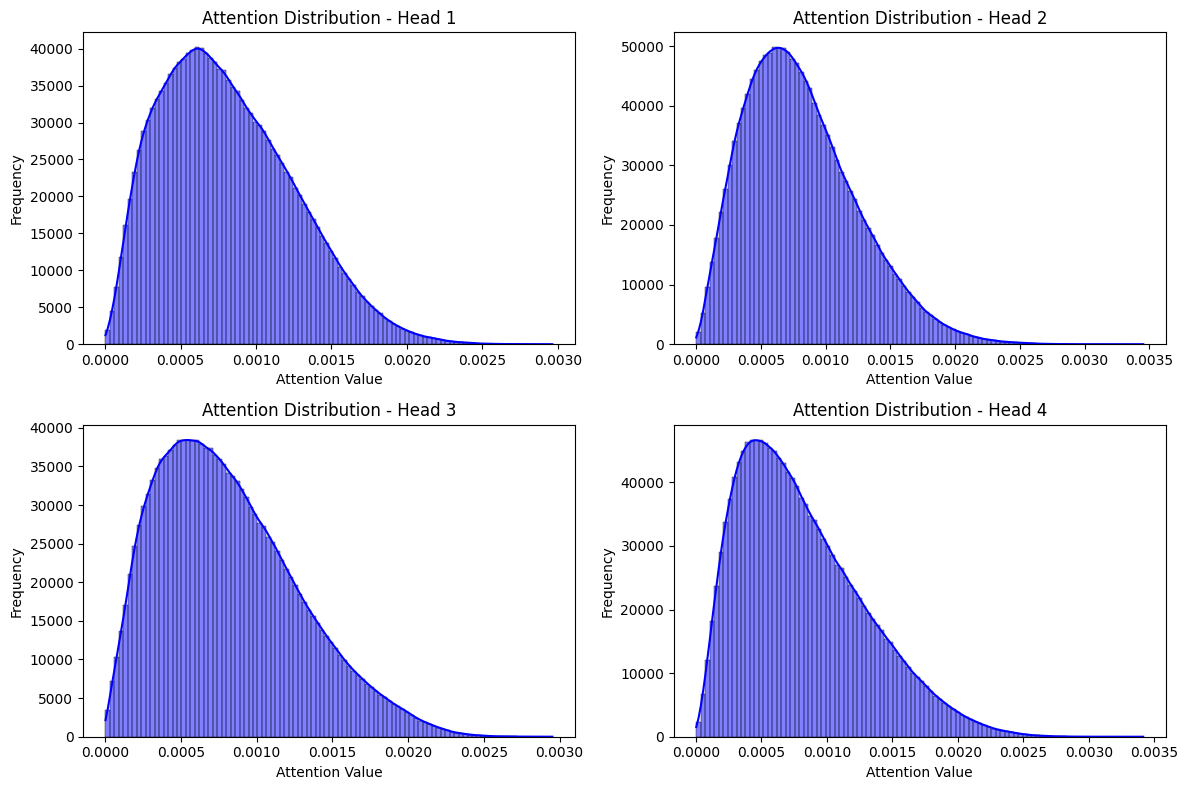

In [196]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i in range(4):
    ax = axes[i // 2, i % 2]
    sns.histplot(attention_edge_lengths_layer0_df[i]['attention'], bins=100, ax=ax, color='blue', kde=True)
    ax.set_title(f'Attention Distribution - Head {i+1}')
    ax.set_xlabel('Attention Value')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

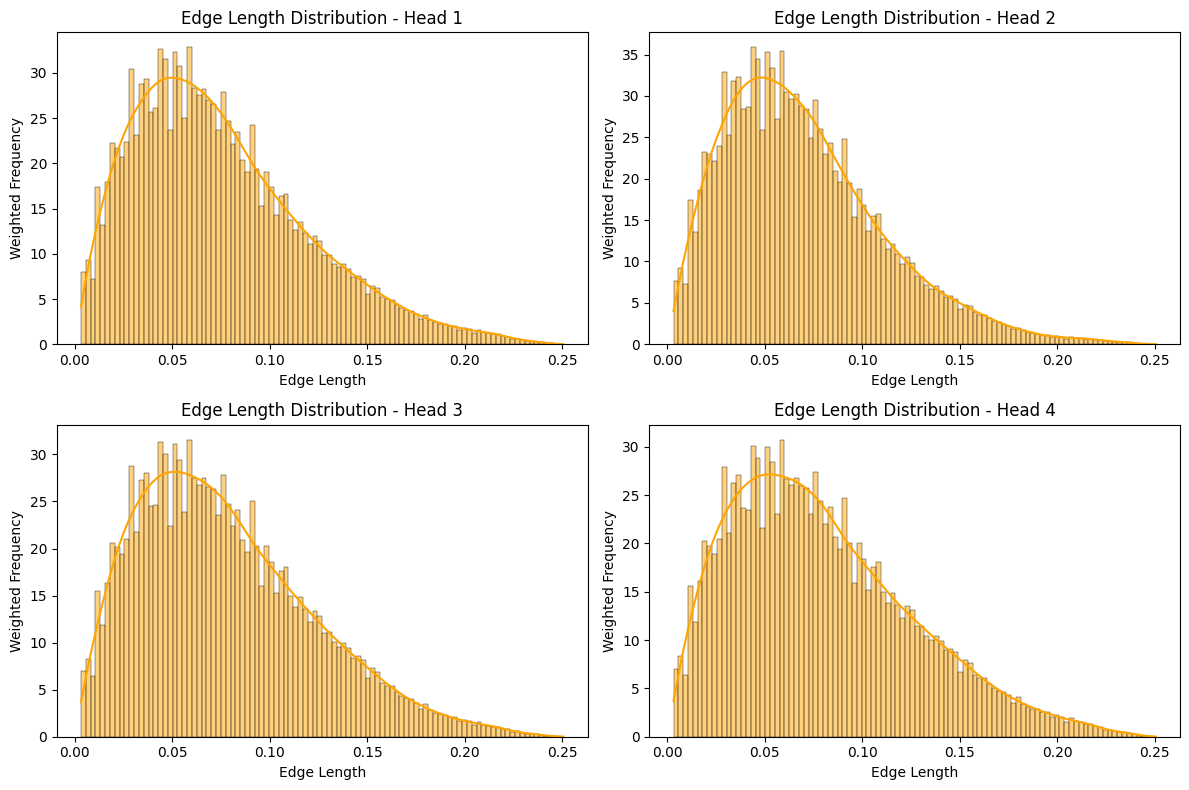

In [197]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i in range(4):
    ax = axes[i // 2, i % 2]
    # Use the data parameter and specify column names
    sns.histplot(
        data=attention_edge_lengths_layer1_df[i], 
        x='length',
        weights='attention',
        bins=100, 
        ax=ax, 
        color='orange', 
        kde=True
    )
    ax.set_title(f'Edge Length Distribution - Head {i+1}')
    ax.set_xlabel('Edge Length')
    ax.set_ylabel('Weighted Frequency')
plt.tight_layout()
plt.show()

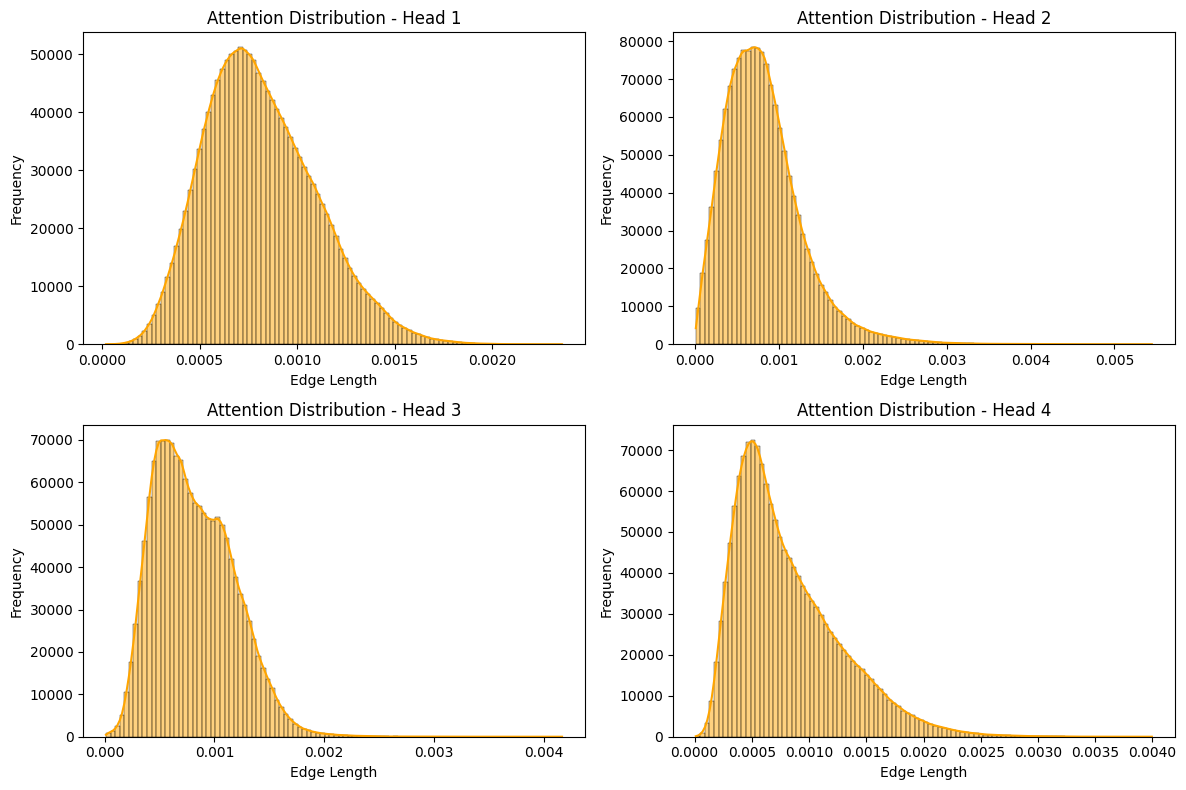

In [198]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i in range(4):
    ax = axes[i // 2, i % 2]
    sns.histplot(attention_edge_lengths_layer1_df[i]['attention'], bins=100, ax=ax, color='orange', kde=True)
    ax.set_title(f'Attention Distribution - Head {i+1}')
    ax.set_xlabel('Edge Length')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [201]:
# Average the attention with the distance
mean_attentions_layer0 = {}
for head in range(4):
    mean_attentions_layer0[head] = (attention_edge_lengths_layer0_df[head]['attention']*attention_edge_lengths_layer0_df[head]['length']).sum() / attention_edge_lengths_layer0_df[head]['length'].sum()
    print(f"Mean attention for head {head}: {mean_attentions_layer0[head]:.6f}")

Mean attention for head 0: 0.000818
Mean attention for head 1: 0.000814
Mean attention for head 2: 0.000814
Mean attention for head 3: 0.000809


In [202]:
mean_attentions_layer1 = {}
for head in range(4):
    mean_attentions_layer1[head] = (attention_edge_lengths_layer1_df[head]['attention']*attention_edge_lengths_layer1_df[head]['length']).sum() / attention_edge_lengths_layer1_df[head]['length'].sum()
    print(f"Mean attention for head {head}: {mean_attentions_layer1[head]:.6f}")

Mean attention for head 0: 0.000831
Mean attention for head 1: 0.000776
Mean attention for head 2: 0.000859
Mean attention for head 3: 0.000882


To me this does not look like overfitting, even though for sure this many features are not needed, still the mean attention weighted on the lenght looks identical to the previous model
- Next step should be to create a deeper model and see if something changes
